In [ ]:
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal as scipy_signal
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, auc
)
from sklearn.impute import SimpleImputer
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_selection import RFE
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import StackingClassifier
from sklearn.base import clone
from functions import load_subject_data, create_windows, stat_features, freq_features, eda_extra_features, extract_window_features

In [2]:
import random
import os

# global seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# 1. Creation of Constants

In [3]:
# Constants
DATA_PATH = Path('WESAD')
SUBJECT_IDS = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]
LABEL_MAP = {1: 'Baseline', 2: 'Stress', 3: 'Amusement'}
WRIST_SAMPLING_RATES = {'ACC': 32, 'BVP': 64, 'EDA': 4, 'TEMP': 4}
LABEL_SAMPLING_RATE = 700
WINDOW_SIZE_SEC = 30  # 30-second windows
WINDOW_SHIFT_SEC = 5  # 5-second sliding step
VALID_LABELS = [1, 2, 3]
# Binary mapping: 0 = Non-Stress (baseline + amusement), 1 = Stress
BINARY_MAP = {1: 0, 2: 1, 3: 0}
BINARY_LABEL_NAMES = ['Non-Stress', 'Stress']

print(f"Subjects: {SUBJECT_IDS}")
print(f"Window size: {WINDOW_SIZE_SEC}s")

Subjects: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]
Window size: 30s


# 2. Data Loading & Exploration

In [ ]:
# Section: Data Loading 
all_subjects_data = {}

for sid in SUBJECT_IDS:
    print(f"Loading S{sid}... ", end="")
    # load pkl (contains both wrist and chest)
    data = load_subject_data(DATA_PATH, sid)
    
    # Remove Resbian (chest) data following instructions 
    wrist_only_data = {
        'signal': {'wrist': data['signal']['wrist']},
        'label': data['label']
    }
    
    all_subjects_data[sid] = wrist_only_data
    print("OK (Wrist data only)")

print(f"\nLoaded {len(all_subjects_data)} subjects successfully.")

# Section: Preprocessing & Windowing
all_windows = {}
all_labels_dict = {}

print("Starting Windowing (Filters will be applied during feature extraction)...")

for sid in SUBJECT_IDS:
    w, l = create_windows(
        all_subjects_data[sid], 
        WINDOW_SIZE_SEC, 
        WINDOW_SHIFT_SEC, 
        LABEL_SAMPLING_RATE, 
        WRIST_SAMPLING_RATES, 
        VALID_LABELS
    )
    
    all_windows[sid] = w
    all_labels_dict[sid] = l
    
    unique, counts = np.unique(l, return_counts=True)
    dist = ", ".join([f"{LABEL_MAP[int(u)]}={c}" for u, c in zip(unique, counts)])
    print(f"S{sid}: {len(w)} valid windows ({dist})")

total_windows = sum(len(v) for v in all_windows.values())
print(f"\nTotal preprocessed windows: {total_windows}")

Loading S2... OK (Wrist data only)
Loading S3... OK (Wrist data only)
Loading S4... OK (Wrist data only)
Loading S5... OK (Wrist data only)
Loading S6... OK (Wrist data only)
Loading S7... OK (Wrist data only)
Loading S8... OK (Wrist data only)
Loading S9... OK (Wrist data only)
Loading S10... OK (Wrist data only)
Loading S11... OK (Wrist data only)
Loading S13... OK (Wrist data only)
Loading S14... OK (Wrist data only)
Loading S15... OK (Wrist data only)
Loading S16... OK (Wrist data only)
Loading S17... OK (Wrist data only)

Loaded 15 subjects successfully.
Starting Windowing (Filters will be applied during feature extraction)...
S2: 413 valid windows (Baseline=225, Stress=119, Amusement=69)
S3: 419 valid windows (Baseline=224, Stress=124, Amusement=71)
S4: 422 valid windows (Baseline=228, Stress=123, Amusement=71)
S5: 432 valid windows (Baseline=236, Stress=125, Amusement=71)
S6: 430 valid windows (Baseline=232, Stress=127, Amusement=71)
S7: 429 valid windows (Baseline=234, Stress=1

In [5]:
sid = SUBJECT_IDS[0]
sample = all_subjects_data[sid]

print(f"Subject: S{sid}") 
print(f"Top-level keys: {list(sample.keys())}")
print(f"Signal keys: {list(sample['signal'].keys())}")
print(f"Wrist signal keys: {list(sample['signal']['wrist'].keys())}")

print(f"\nWrist signal shapes:")
for key, val in sample['signal']['wrist'].items():
    sr = WRIST_SAMPLING_RATES[key]
    duration = len(val) / sr
    print(f"  {key}: shape={val.shape}, rate={sr}Hz, duration={duration:.1f}s")

print(f"\nLabel shape: {sample['label'].shape}")
print(f"Label duration: {len(sample['label']) / LABEL_SAMPLING_RATE:.1f}s")

print(f"\nLabel distribution (S{sid}):")
unique, counts = np.unique(sample['label'], return_counts=True)
for u, c in zip(unique, counts):
    name = LABEL_MAP.get(int(u), f"Other({int(u)})")
    print(f"  {name}: {c} samples = {c/LABEL_SAMPLING_RATE:.1f}s")

Subject: S2
Top-level keys: ['signal', 'label']
Signal keys: ['wrist']
Wrist signal keys: ['ACC', 'BVP', 'EDA', 'TEMP']

Wrist signal shapes:
  ACC: shape=(194528, 3), rate=32Hz, duration=6079.0s
  BVP: shape=(389056, 1), rate=64Hz, duration=6079.0s
  EDA: shape=(24316, 1), rate=4Hz, duration=6079.0s
  TEMP: shape=(24316, 1), rate=4Hz, duration=6079.0s

Label shape: (4255300,)
Label duration: 6079.0s

Label distribution (S2):
  Other(0): 2142701 samples = 3061.0s
  Baseline: 800800 samples = 1144.0s
  Stress: 430500 samples = 615.0s
  Amusement: 253400 samples = 362.0s
  Other(4): 537599 samples = 768.0s
  Other(6): 45500 samples = 65.0s
  Other(7): 44800 samples = 64.0s


In [6]:
# Dataset statistics across all subjects
stats_rows = []
for sid in SUBJECT_IDS:
    labels = all_subjects_data[sid]['label'].flatten()
    for lv in VALID_LABELS:
        count = int(np.sum(labels == lv))
        stats_rows.append({
            'Subject': f'S{sid}',
            'Class': LABEL_MAP[lv],
            'Duration_s': round(count / LABEL_SAMPLING_RATE, 1)
        })

stats_df = pd.DataFrame(stats_rows)
pivot = stats_df.pivot_table(index='Subject', columns='Class', values='Duration_s')
print("Duration per class per subject (seconds):")
print(pivot.to_string())
print(f"\nTotal per class:\n{stats_df.groupby('Class')['Duration_s'].sum()}")


Duration per class per subject (seconds):
Class    Amusement  Baseline  Stress
Subject                             
S10          372.0    1180.0   725.0
S11          368.0    1180.0   680.0
S13          382.0    1180.0   664.0
S14          372.0    1180.0   675.0
S15          372.0    1175.0   686.0
S16          368.0    1180.0   673.0
S17          372.0    1181.0   723.0
S2           362.0    1144.0   615.0
S3           375.0    1140.0   640.0
S4           372.0    1158.0   635.0
S5           374.0    1198.0   645.0
S6           372.0    1180.0   650.0
S7           372.0    1186.0   640.0
S8           370.0    1169.0   670.0
S9           372.0    1180.0   645.0

Total per class:
Class
Amusement     5575.0
Baseline     17611.0
Stress        9966.0
Name: Duration_s, dtype: float64


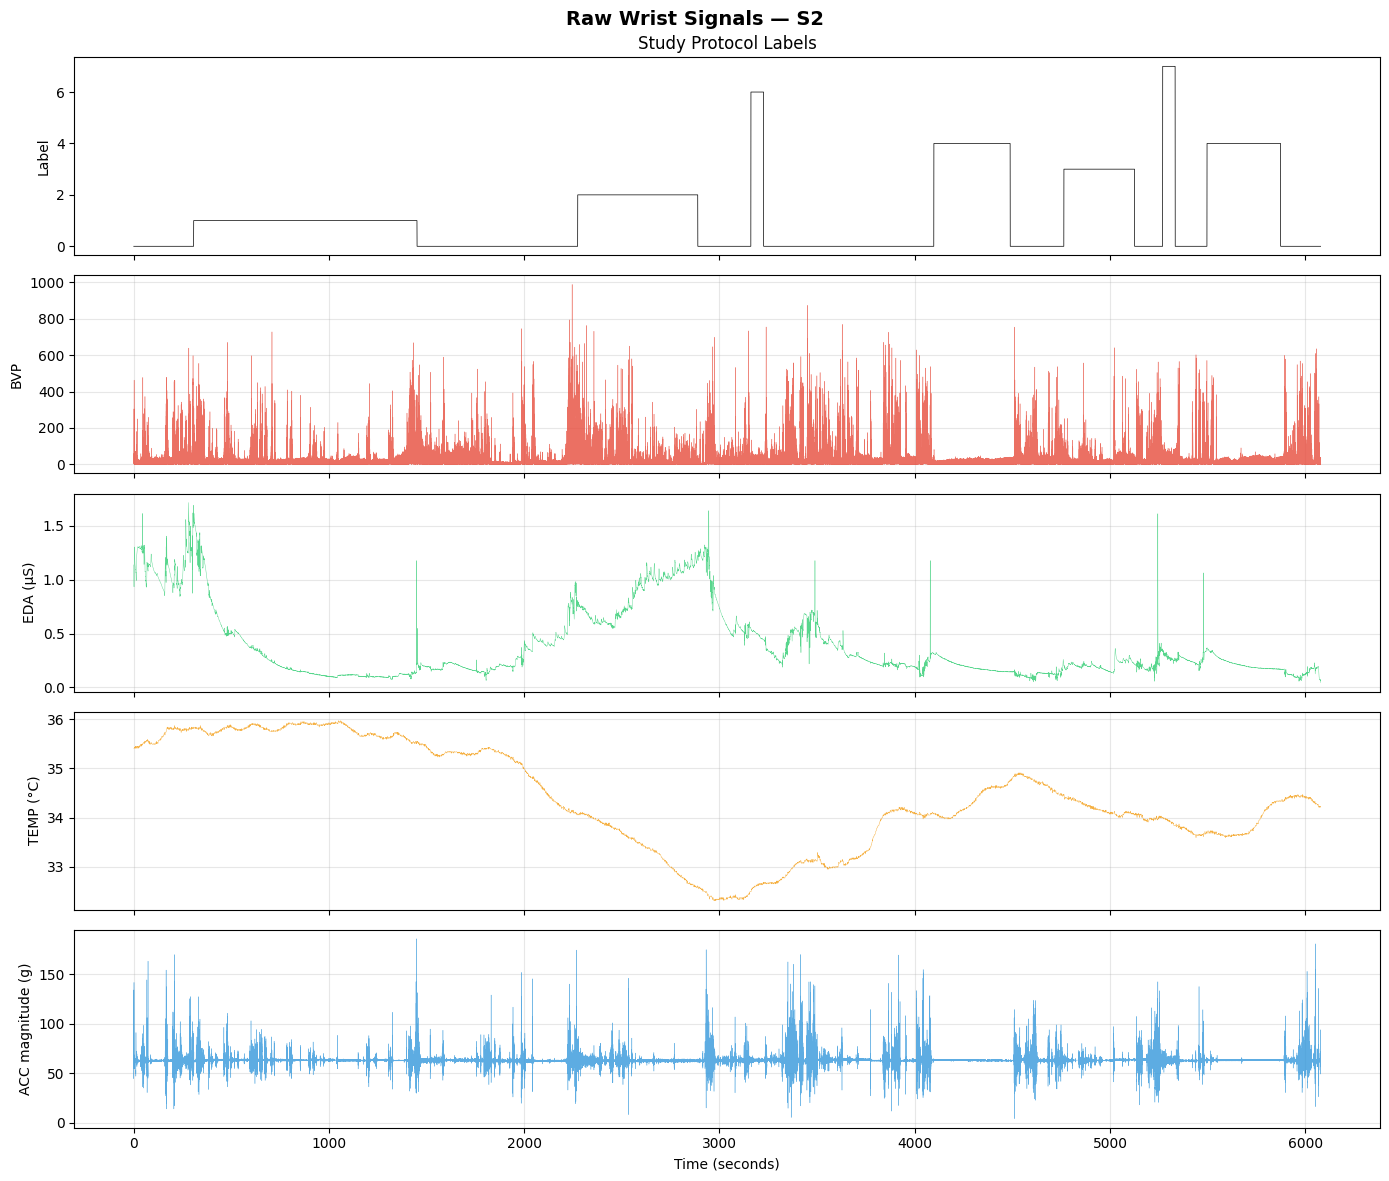

In [7]:
# Visualize raw wrist signals for one subject 
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
fig.suptitle(f"Raw Wrist Signals — S{SUBJECT_IDS[0]}", fontsize=14, fontweight='bold')

wrist = sample['signal']['wrist']
labels = sample['label'].flatten()

# Plot labels
t_labels = np.arange(len(labels)) / LABEL_SAMPLING_RATE
axes[0].plot(t_labels, labels, color='black', linewidth=0.5)
axes[0].set_ylabel('Label')
axes[0].set_title('Study Protocol Labels')

# Plot each wrist signal
signal_list = [
    ('BVP', 'BVP', '#e74c3c'),
    ('EDA', 'EDA (μS)', '#2ecc71'),
    ('TEMP', 'TEMP (°C)', '#f39c12'),
    ('ACC', 'ACC magnitude (g)', '#3498db'),
]

for i, (key, ylabel, color) in enumerate(signal_list):
    ax = axes[i + 1]
    sr = WRIST_SAMPLING_RATES[key]
    data = wrist[key]
    if data.ndim > 1:
        data = np.linalg.norm(data, axis=1)
    else:
        data = data.flatten()
    t = np.arange(len(data)) / sr
    ax.plot(t, data, color=color, linewidth=0.3, alpha=0.8)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (seconds)')
plt.tight_layout()
plt.show()


# Section 3: Preprocessing & Windowing

Segment all wrist signals into **30-second** fixed windows with a 5-second sliding shift. Each window gets a label via **majority vote** from the 700 Hz label stream. Windows with ambiguous labels (majority < 80%) or invalid labels (0, 4–7) are discarded.

Features are extracted at each signal's **native sampling rate** to preserve information.


In [ ]:
# Process all subjects 
all_windows = {}
all_labels_dict = {}

for sid in SUBJECT_IDS:
    w, l = create_windows(all_subjects_data[sid], WINDOW_SIZE_SEC, WINDOW_SHIFT_SEC, LABEL_SAMPLING_RATE, WRIST_SAMPLING_RATES, VALID_LABELS)
    all_windows[sid] = w
    all_labels_dict[sid] = l
    unique, counts = np.unique(l, return_counts=True)
    dist = ", ".join([f"{LABEL_MAP[int(u)]}={c}" for u, c in zip(unique, counts)])
    print(f"S{sid}: {len(w)} windows ({dist})")

total = sum(len(v) for v in all_windows.values())
print(f"\nTotal windows: {total}")


S2: 413 windows (Baseline=225, Stress=119, Amusement=69)
S3: 419 windows (Baseline=224, Stress=124, Amusement=71)
S4: 422 windows (Baseline=228, Stress=123, Amusement=71)
S5: 432 windows (Baseline=236, Stress=125, Amusement=71)
S6: 430 windows (Baseline=232, Stress=127, Amusement=71)
S7: 429 windows (Baseline=234, Stress=124, Amusement=71)
S8: 430 windows (Baseline=230, Stress=130, Amusement=70)
S9: 429 windows (Baseline=233, Stress=125, Amusement=71)
S10: 444 windows (Baseline=232, Stress=141, Amusement=71)
S11: 435 windows (Baseline=233, Stress=132, Amusement=70)
S13: 435 windows (Baseline=232, Stress=130, Amusement=73)
S14: 435 windows (Baseline=232, Stress=132, Amusement=71)
S15: 436 windows (Baseline=232, Stress=134, Amusement=70)
S16: 433 windows (Baseline=232, Stress=131, Amusement=70)
S17: 444 windows (Baseline=232, Stress=141, Amusement=71)

Total windows: 6466


# Section 4 — Feature Extraction


 Wrist-worn EDA and BVP sensors are highly susceptible to motion artifacts. While the BVP signal is passed through a 0.5-4 Hz bandpass filter to isolate the cardiac frequency band, explicitly removing all motion artifacts from EDA data is notoriously difficult without corrupting the underlying physiological response. To address this, our pipeline relies heavily on robust statistical features (e.g., median, MAD) rather than relying solely on pure point-in-time amplitudes, naturally dampening the impact of sudden mechanical artifacts in the windows.

For each 5-second window, extract **time-domain** and **frequency-domain** features from all wrist signals:
- **Statistical**: mean, std, min, max, median, range, skewness, kurtosis, RMS, mean absolute deviation, sum of absolute differences
- **Frequency**: total power, dominant frequency, spectral entropy (via Welch's method)
- **EDA-specific**: number of peaks, mean peak height, derivative statistics

In [9]:
# Build the feature matrix 
print("Extracting features from all windows...")

feature_rows = []
label_rows = []
group_rows = []

for sid in SUBJECT_IDS:
    n = len(all_windows[sid])
    print(f"  S{sid}: {n} windows...", end=" ")
    for window, label in zip(all_windows[sid], all_labels_dict[sid]):
        feature_rows.append(extract_window_features(window, WRIST_SAMPLING_RATES))
        label_rows.append(BINARY_MAP[label])
        group_rows.append(sid)
    print("done")

X = pd.DataFrame(feature_rows)
y = np.array(label_rows)
groups = np.array(group_rows)

# we let it remain NaN globally
# later, inside our CV loops, we use SimpleImputer(strategy='median'). Filling with 0 globally can distort the natural distribution of our features
X = X.replace([np.inf, -np.inf], np.nan)

print(f"\nFeature matrix: {X.shape[0]} samples X {X.shape[1]} features")
print(f"Non-Stress: {np.sum(y == 0)}, Stress: {np.sum(y == 1)}")
print(f"\nFeatures ({X.shape[1]}):")
for i, c in enumerate(X.columns, 1):
    print(f"  {i:3d}. {c}")


Extracting features from all windows...
  S2: 413 windows... done
  S3: 419 windows... done
  S4: 422 windows... done
  S5: 432 windows... done
  S6: 430 windows... done
  S7: 429 windows... done
  S8: 430 windows... done
  S9: 429 windows... done
  S10: 444 windows... done
  S11: 435 windows... done
  S13: 435 windows... done
  S14: 435 windows... done
  S15: 436 windows... done
  S16: 433 windows... done
  S17: 444 windows... done

Feature matrix: 6466 samples X 99 features
Non-Stress: 4528, Stress: 1938

Features (99):
    1. ACC_x_mean
    2. ACC_x_std
    3. ACC_x_min
    4. ACC_x_max
    5. ACC_x_median
    6. ACC_x_range
    7. ACC_x_skew
    8. ACC_x_kurtosis
    9. ACC_x_rms
   10. ACC_x_mad
   11. ACC_x_sad
   12. ACC_x_total_power
   13. ACC_x_dom_freq
   14. ACC_x_spectral_entropy
   15. ACC_y_mean
   16. ACC_y_std
   17. ACC_y_min
   18. ACC_y_max
   19. ACC_y_median
   20. ACC_y_range
   21. ACC_y_skew
   22. ACC_y_kurtosis
   23. ACC_y_rms
   24. ACC_y_mad
   25. ACC_y_s

### 4.2 — HRV Feature Extraction from BVP

Heart Rate Variability (HRV) is one of the most validated physiological markers of stress.
From the 64 Hz BVP (blood volume pulse) signal we detect systolic peaks and compute:
- **Time-domain**: MeanHR, SDNN, RMSSD, pNN50
- **Frequency-domain**: LF power (0.04–0.15 Hz), HF power (0.15–0.4 Hz), LF/HF ratio

These features are appended to the existing 99-feature matrix, bringing the total to **107 features**.

In [ ]:
from scipy.signal import find_peaks

BVP_FS = WRIST_SAMPLING_RATES['BVP']   # 64 Hz

def extract_hrv_features(window, fs=BVP_FS):
    """Extract time- and frequency-domain HRV from a BVP window dict."""
    bvp = window['BVP'].flatten().astype(float)

    # --- bandpass 0.5–4 Hz (30–240 bpm) ---
    b, a = scipy_signal.butter(4, [0.5, 4.0], btype='bandpass', fs=fs)
    bvp_f = scipy_signal.filtfilt(b, a, bvp)

    # --- peak detection ---
    min_dist = int(fs * 0.4)            # ≥ 0.4 s between beats (≤150 bpm)
    peaks, props = find_peaks(bvp_f, distance=min_dist,
                              prominence=np.percentile(np.abs(bvp_f), 25))

    feats = {}
    zero = dict(HRV_MeanHR=0, HRV_SDNN=0, HRV_RMSSD=0,
                HRV_pNN50=0, HRV_n_beats=0,
                HRV_LF=0, HRV_HF=0, HRV_LFHF=0)

    if len(peaks) < 3:
        return zero

    ibi = np.diff(peaks) / fs           # inter-beat intervals (seconds)

    # time-domain
    feats['HRV_MeanHR'] = 60.0 / np.mean(ibi)
    feats['HRV_SDNN']   = float(np.std(ibi) * 1000)
    feats['HRV_RMSSD']  = float(np.sqrt(np.mean(np.diff(ibi)**2)) * 1000)
    feats['HRV_pNN50']  = float(np.mean(np.abs(np.diff(ibi)) > 0.05) * 100)
    feats['HRV_n_beats']= int(len(peaks))

    # frequency-domain via Welch on resampled IBI tachogram
    if len(ibi) >= 6:
        ibi_t = np.cumsum(ibi); ibi_t -= ibi_t[0]
        t_new = np.arange(0, ibi_t[-1], 0.25)   # 4 Hz resample
        if len(t_new) >= 8:
            ibi_r = np.interp(t_new, ibi_t, ibi)
            ibi_d = ibi_r - np.mean(ibi_r)
            nperseg = min(len(ibi_d), 64)
            freqs, psd = scipy_signal.welch(ibi_d, fs=4.0, nperseg=nperseg)
            lf = np.trapezoid(psd[(freqs>=0.04)&(freqs<0.15)],
                          freqs[(freqs>=0.04)&(freqs<0.15)])
            hf = np.trapezoid(psd[(freqs>=0.15)&(freqs<0.40)],
                          freqs[(freqs>=0.15)&(freqs<0.40)])
            feats['HRV_LF']   = float(lf)
            feats['HRV_HF']   = float(hf)
            feats['HRV_LFHF'] = float(lf / (hf + 1e-9))
            return feats

    feats.update(dict(HRV_LF=0, HRV_HF=0, HRV_LFHF=0))
    return feats

# extract HRV for every window and concat
print("Extracting HRV features from BVP windows...")
hrv_rows = []
for sid in SUBJECT_IDS:
    for window in all_windows[sid]:
        hrv_rows.append(extract_hrv_features(window))

X_hrv = pd.DataFrame(hrv_rows)
X_hrv = X_hrv.replace([np.inf, -np.inf], np.nan).fillna(0)

X = pd.concat([X, X_hrv], axis=1)
print(f"Extended feature matrix: {X.shape[0]} samples x {X.shape[1]} features")
print(f"New HRV features: {X_hrv.columns.tolist()}")


Extracting HRV features from BVP windows...
Extended feature matrix: 6466 samples x 107 features
New HRV features: ['HRV_MeanHR', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_pNN50', 'HRV_n_beats', 'HRV_LF', 'HRV_HF', 'HRV_LFHF']


### Commentary on the Feature Extraction Results

This code block represents the transition from raw physiological signals to the final dataset, ready for Machine Learning. Here is a breakdown of what was done and the results obtained:

*   **Building Matrix X:** For each subject, the algorithm examined the previously created time windows and extracted 99 mathematical features (e.g., mean, standard deviation, frequency power, entropy) using the `extract_window_features` function[cite: 1, 3]. The result is a DataFrame `X` containing 6466 samples (rows) and 99 columns[cite: 3].
*   **Binary Mapping (Array y):** The original WESAD protocol labels were converted into a binary classification problem using the `BINARY_MAP` variable[cite: 3]. The "Baseline" (1) and "Amusement" (3) states were merged into class **0 (Non-Stress)**, while the "Stress" condition (2) became class **1 (Stress)**[cite: 3].
*   **Preparation for LOSO (Array groups):** The `groups` array stores the subject ID (`sid`) associated with each individual window[cite: 3]. This array is the foundation that allows us to correctly execute the Leave-One-Subject-Out Cross-Validation, ensuring that the data of a subject used for testing never ends up in the training set[cite: 2, 3].
*   **Handling Anomalous Data:** The line `X.replace([np.inf, -np.inf], np.nan).fillna(0)` is a safety measure[cite: 3]. It transforms any infinite or missing values (which can occasionally occur during divisions when calculating frequency features) into zeros, preventing the ML models from crashing[cite: 3].
*   **Class Imbalance Analysis:** The output reveals a clear imbalance: **4528 Non-Stress samples versus 1938 Stress samples**[cite: 3]. This reflects the actual structure of the experimental protocol (the baseline and relaxation phases simply last longer than the acute stress phase). This imbalance justifies the use of the `class_weight='balanced'` parameter in our Logistic Regression and reminds us to evaluate performance using the F1-Score rather than just simple Accuracy[cite: 3].
*   **Analyzed Subjects:** As noted in the logs, the subjects start from S2 and skip S1 and S12[cite: 3]. This aligns with the original WESAD dataset, where data for S1 and S12 were discarded due to sensor malfunctions[cite: 2].

# Section 5. Feature Analysis

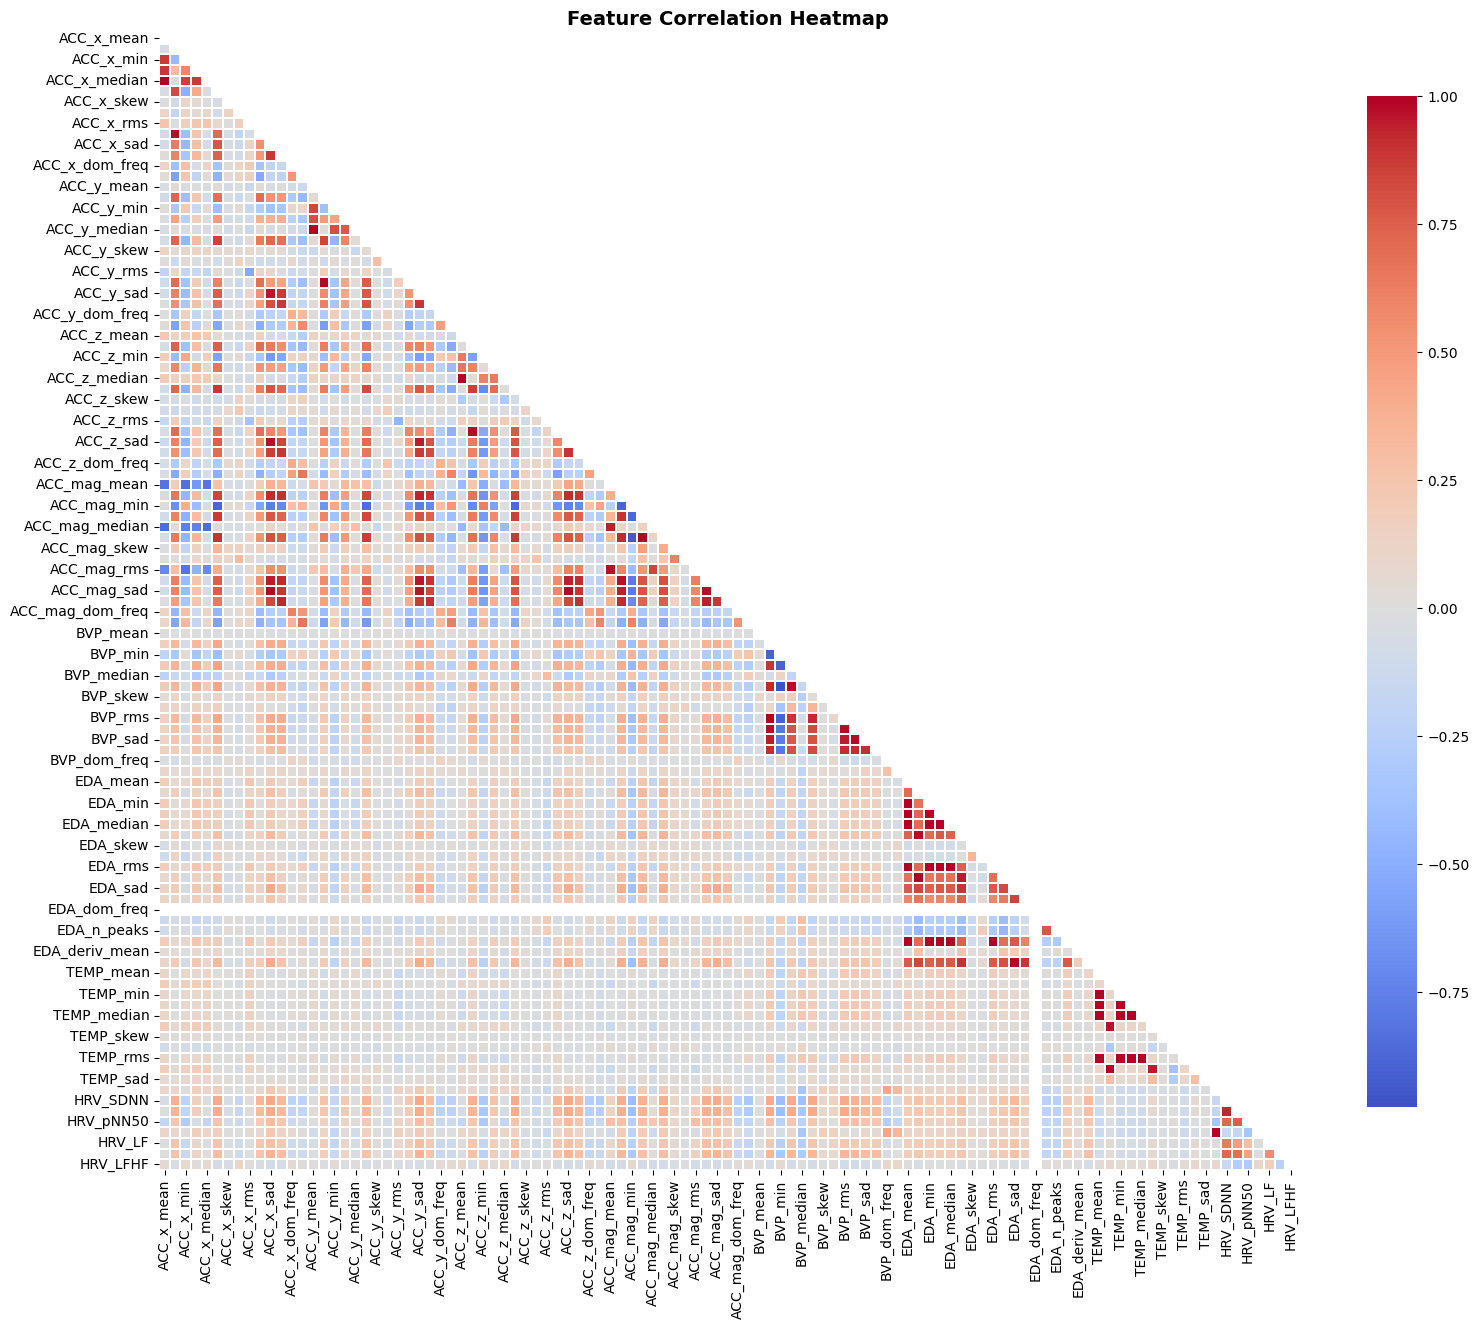

In [11]:
# Correlation heatmap
plt.figure(figsize=(16, 14))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=0.3, annot=False,
            cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

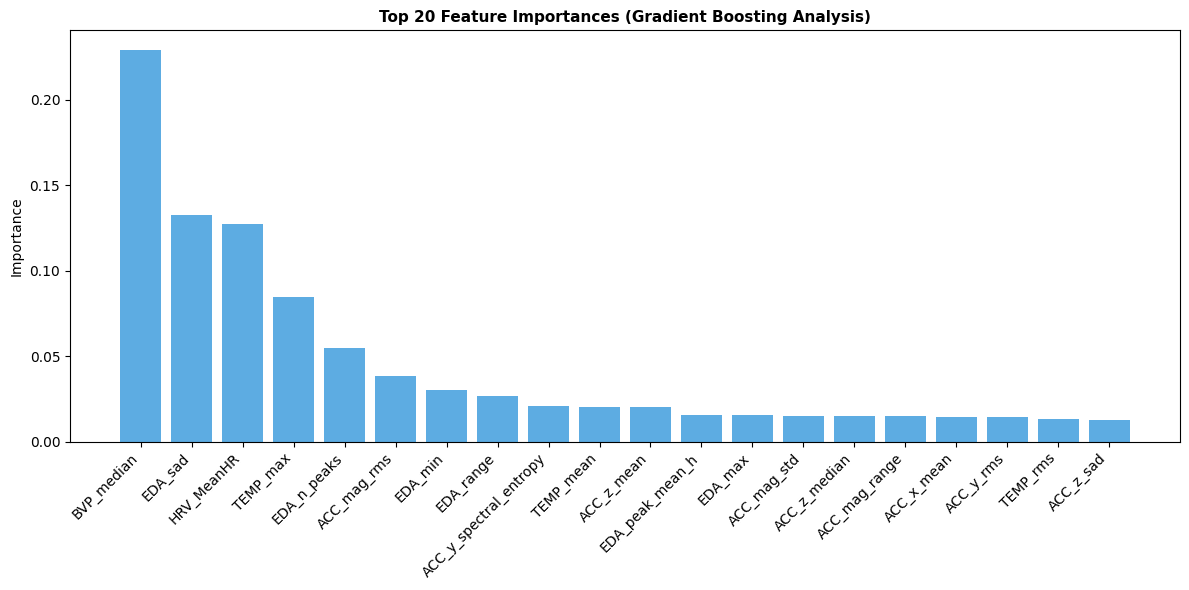

In [ ]:
# Impute the missing values with the median
imputer_tmp = SimpleImputer(strategy='median')
X_imputed = imputer_tmp.fit_transform(X)

# Scale the cleaned data
scaler_tmp = StandardScaler()
X_tmp = scaler_tmp.fit_transform(X_imputed)

# Fit the Gradient Boosting model
gb_analysis = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_analysis.fit(X_tmp, y)

# Extract and plot importances
importances = gb_analysis.feature_importances_
top_idx = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 6))
plt.bar(range(20), importances[top_idx], color='#3498db', alpha=0.8)
plt.xticks(range(20), [X.columns[i] for i in top_idx], rotation=45, ha='right')
plt.title('Top 20 Feature Importances (Gradient Boosting Analysis)', fontsize=11, fontweight='bold')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

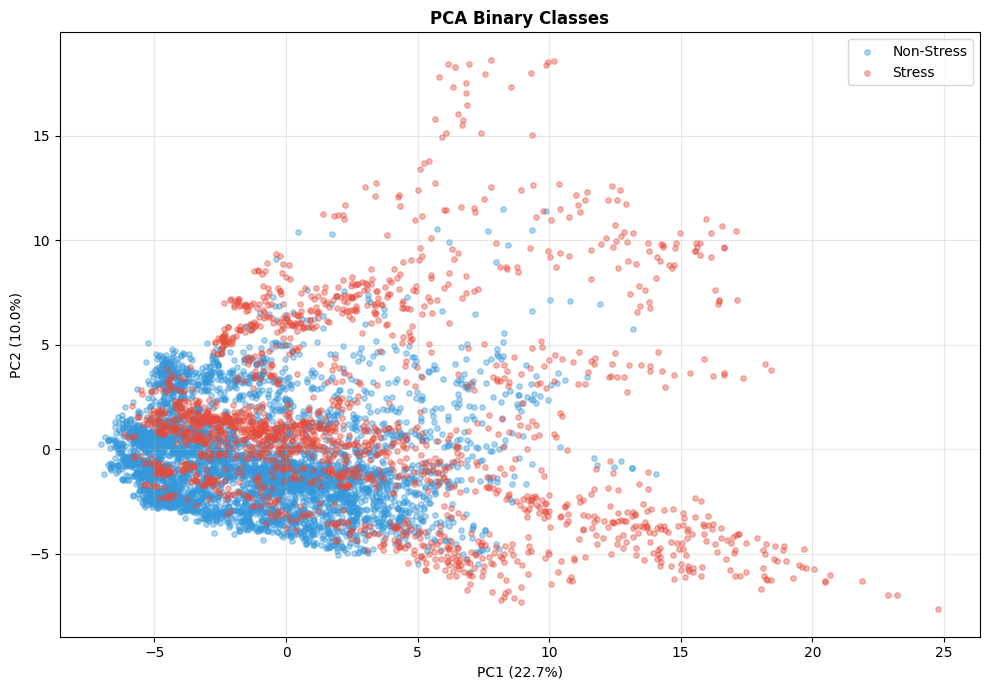

Explained variance (2 PCs): 32.7%


In [ ]:
# Impute missing values to a temporary array specifically for PCA
imputer_pca = SimpleImputer(strategy='median')
X_imputed_for_pca = imputer_pca.fit_transform(X)

# Scale the imputed data
scaler_pca = StandardScaler()
X_pca_in = scaler_pca.fit_transform(X_imputed_for_pca)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_pca_in)

plt.figure(figsize=(10, 7))
for lv, color, name in zip([0, 1], ['#3498db', '#e74c3c'], BINARY_LABEL_NAMES):
    m = y == lv
    plt.scatter(X_pca[m, 0], X_pca[m, 1], c=color, label=name, alpha=0.4, s=15)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA Binary Classes', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Explained variance (2 PCs): {sum(pca.explained_variance_ratio_)*100:.1f}%")

# Section 6. Model Development

Models chosen to be **different from the original WESAD paper** (which used DT, RF, AdaBoost, LDA, kNN):
1. **Logistic Regression**
2. **SVM** (RBF kernel)
3. **Gradient Boosting** (sklearn)
4. **MLP** (Multi-Layer Perceptron)

Cross Validation employed for the models is: 

**Leave-One-Subject-Out**: train on 14 subjects, test on 1. Ensures subject-independent evaluation.

In [15]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42, class_weight='balanced'),
    'SVM (RBF)': SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(128, 64), max_iter=500,
        early_stopping=True, validation_fraction=0.1, random_state=42
    ),
}


In [16]:
# LOSO CV 
logo = LeaveOneGroupOut()
results = {name: {'y_true': [], 'y_pred': [], 'y_prob': [], 'subjects': []}
           for name in models}

n_folds = logo.get_n_splits(X, y, groups)
print(f"Running LOSO Cross-Validation ({n_folds} folds)")
print(f"Features: {X.shape[1]}  |  Samples: {X.shape[0]}")
print("=" * 70)

for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups)):
    test_subj = groups[test_idx[0]]
    print(f"\nFold {fold+1}/{n_folds}: test on S{test_subj} "
          f"(train={len(train_idx)}, test={len(test_idx)})")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    imputer = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp = imputer.transform(X_test)

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train_imp)
    X_te = scaler.transform(X_test_imp)

    for mname, model in models.items():
        m = clone(model)
        m.fit(X_tr, y_train)
        preds = m.predict(X_te)
        probs = m.predict_proba(X_te)[:, 1]

        results[mname]['y_true'].extend(y_test)
        results[mname]['y_pred'].extend(preds)
        results[mname]['y_prob'].extend(probs)
        results[mname]['subjects'].extend([test_subj] * len(y_test))

        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds)
        print(f"  {mname}: Acc={acc:.3f}, F1={f1:.3f}")

print("\n" + "=" * 70)
print("LOSO Cross-Validation complete!")

Running LOSO Cross-Validation (15 folds)
Features: 107  |  Samples: 6466

Fold 1/15: test on S2 (train=6053, test=413)
  Logistic Regression: Acc=0.644, F1=0.026
  SVM (RBF): Acc=0.748, F1=0.435
  Gradient Boosting: Acc=0.852, F1=0.667
  MLP: Acc=0.736, F1=0.363

Fold 2/15: test on S3 (train=6047, test=419)
  Logistic Regression: Acc=0.876, F1=0.798
  SVM (RBF): Acc=0.914, F1=0.835
  Gradient Boosting: Acc=0.959, F1=0.936
  MLP: Acc=0.907, F1=0.840

Fold 3/15: test on S4 (train=6044, test=422)
  Logistic Regression: Acc=0.998, F1=0.996
  SVM (RBF): Acc=0.979, F1=0.962
  Gradient Boosting: Acc=0.998, F1=0.996
  MLP: Acc=0.998, F1=0.996

Fold 4/15: test on S5 (train=6034, test=432)
  Logistic Regression: Acc=0.917, F1=0.867
  SVM (RBF): Acc=0.859, F1=0.734
  Gradient Boosting: Acc=0.856, F1=0.670
  MLP: Acc=0.944, F1=0.911

Fold 5/15: test on S6 (train=6036, test=430)
  Logistic Regression: Acc=0.949, F1=0.910
  SVM (RBF): Acc=0.784, F1=0.635
  Gradient Boosting: Acc=0.928, F1=0.883
  ML

# Section 7. Evaluation

In [17]:
# Overall metrics
print("=" * 70)
print("OVERALL MODEL COMPARISON")
print("=" * 70)

comparison = []
for mname in models:
    yt = np.array(results[mname]['y_true'])
    yp = np.array(results[mname]['y_pred'])

    row = {
        'Model': mname,
        'Accuracy': round(accuracy_score(yt, yp), 4),
        'Precision': round(precision_score(yt, yp), 4),
        'Recall': round(recall_score(yt, yp), 4),
        'F1-Score': round(f1_score(yt, yp), 4),
    }
    comparison.append(row)
    print(f"\n--- {mname} ---")
    print(classification_report(yt, yp, target_names=BINARY_LABEL_NAMES))

comp_df = pd.DataFrame(comparison)
print("\nSummary Table:")
print(comp_df.to_string(index=False))


OVERALL MODEL COMPARISON

--- Logistic Regression ---
              precision    recall  f1-score   support

  Non-Stress       0.93      0.93      0.93      4528
      Stress       0.84      0.84      0.84      1938

    accuracy                           0.90      6466
   macro avg       0.88      0.89      0.89      6466
weighted avg       0.90      0.90      0.90      6466


--- SVM (RBF) ---
              precision    recall  f1-score   support

  Non-Stress       0.90      0.93      0.91      4528
      Stress       0.82      0.75      0.79      1938

    accuracy                           0.88      6466
   macro avg       0.86      0.84      0.85      6466
weighted avg       0.88      0.88      0.88      6466


--- Gradient Boosting ---
              precision    recall  f1-score   support

  Non-Stress       0.91      0.94      0.93      4528
      Stress       0.85      0.79      0.82      1938

    accuracy                           0.89      6466
   macro avg       0.88     

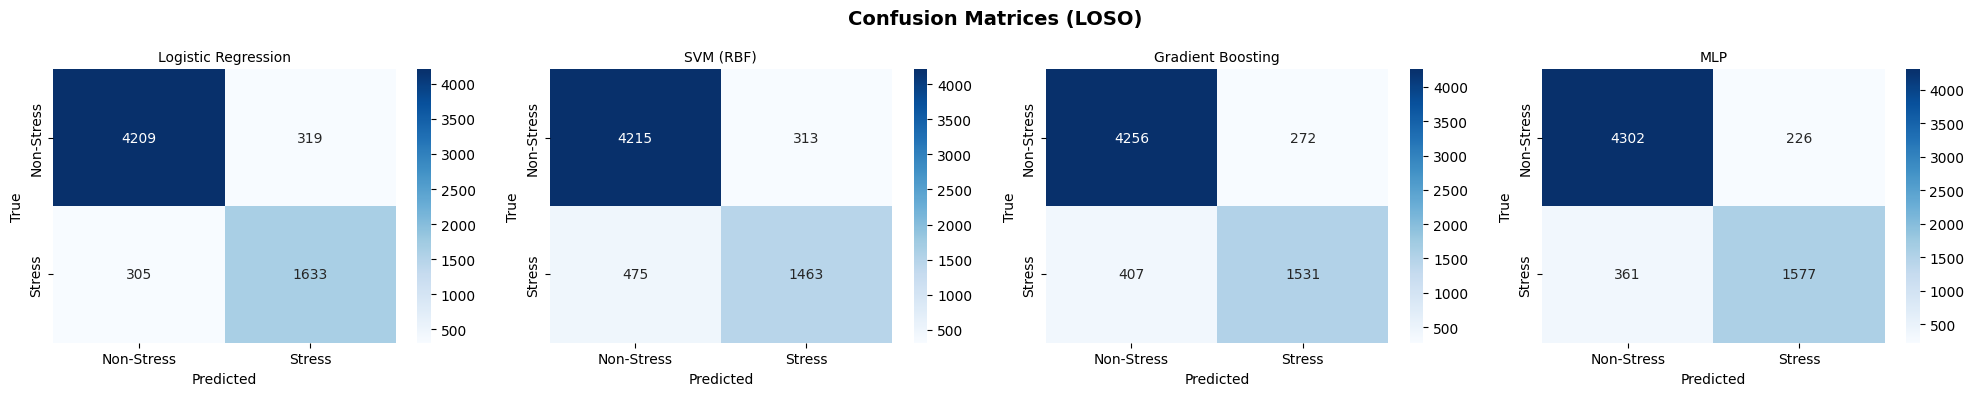

In [18]:
# Confusion matrices 
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4))
fig.suptitle('Confusion Matrices (LOSO)', fontsize=14, fontweight='bold')

for idx, mname in enumerate(models):
    yt = np.array(results[mname]['y_true'])
    yp = np.array(results[mname]['y_pred'])
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=BINARY_LABEL_NAMES, yticklabels=BINARY_LABEL_NAMES)
    axes[idx].set_title(mname, fontsize=10)
    axes[idx].set_ylabel('True')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.show()


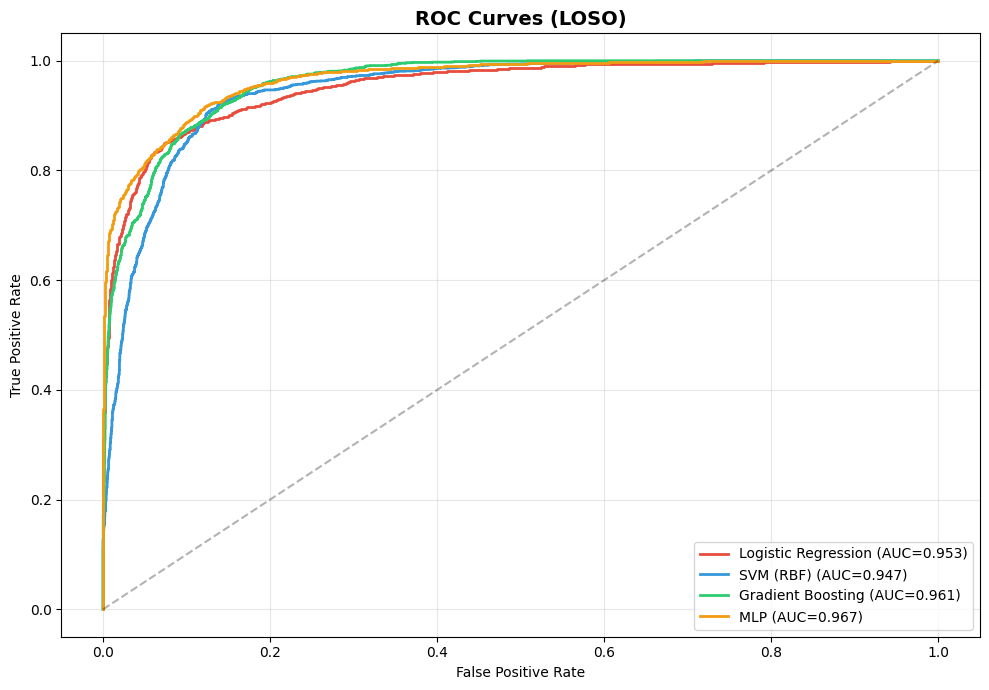

In [19]:
# ROC Curves
plt.figure(figsize=(10, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for mname, color in zip(models, colors):
    yt = np.array(results[mname]['y_true'])
    yp = np.array(results[mname]['y_prob'])
    fpr, tpr, _ = roc_curve(yt, yp)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{mname} (AUC={roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (LOSO)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Best model by F1: MLP

Subject  Accuracy     F1  N_samples  Stress_ratio
     S2    0.7361 0.3626        413         0.288
     S3    0.9069 0.8395        419         0.296
     S4    0.9976 0.9959        422         0.291
     S5    0.9444 0.9111        432         0.289
     S6    0.8326 0.7209        430         0.295
     S7    0.9068 0.8611        429         0.289
     S8    0.9605 0.9300        430         0.302
     S9    0.7809 0.3974        429         0.291
    S10    0.9797 0.9689        444         0.318
    S11    1.0000 1.0000        435         0.303
    S13    0.9402 0.9091        435         0.299
    S14    0.9471 0.9139        435         0.303
    S15    0.8486 0.7179        436         0.307
    S16    0.9492 0.9225        433         0.303
    S17    0.8986 0.8148        444         0.318


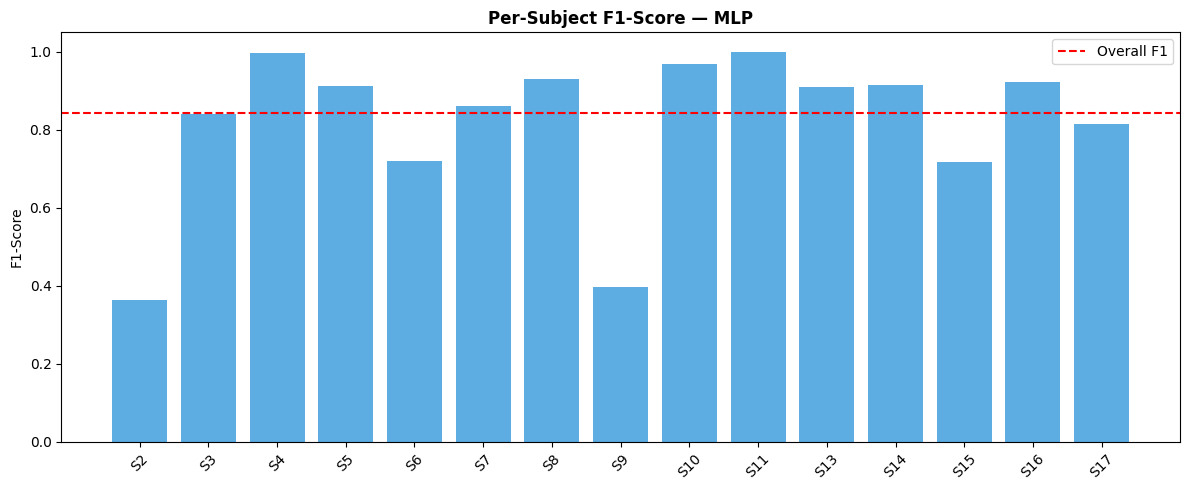

In [20]:
# Per-subject performance (best model) 
best_model = comp_df.loc[comp_df['F1-Score'].idxmax(), 'Model']
print(f"Best model by F1: {best_model}\n")

per_subj = []
for sid in SUBJECT_IDS:
    mask = np.array(results[best_model]['subjects']) == sid
    yt = np.array(results[best_model]['y_true'])[mask]
    yp = np.array(results[best_model]['y_pred'])[mask]
    per_subj.append({
        'Subject': f'S{sid}',
        'Accuracy': round(accuracy_score(yt, yp), 4),
        'F1': round(f1_score(yt, yp, zero_division=0), 4),
        'N_samples': len(yt),
        'Stress_ratio': round(np.mean(yt), 3),
    })

per_subj_df = pd.DataFrame(per_subj)
print(per_subj_df.to_string(index=False))

# Plot per-subject F1
plt.figure(figsize=(12, 5))
plt.bar(per_subj_df['Subject'], per_subj_df['F1'], color='#3498db', alpha=0.8)
plt.axhline(y=comp_df.loc[comp_df['Model'] == best_model, 'F1-Score'].values[0],
            color='red', linestyle='--', label='Overall F1')
plt.ylabel('F1-Score')
plt.title(f'Per-Subject F1-Score — {best_model}', fontsize=12, fontweight='bold')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


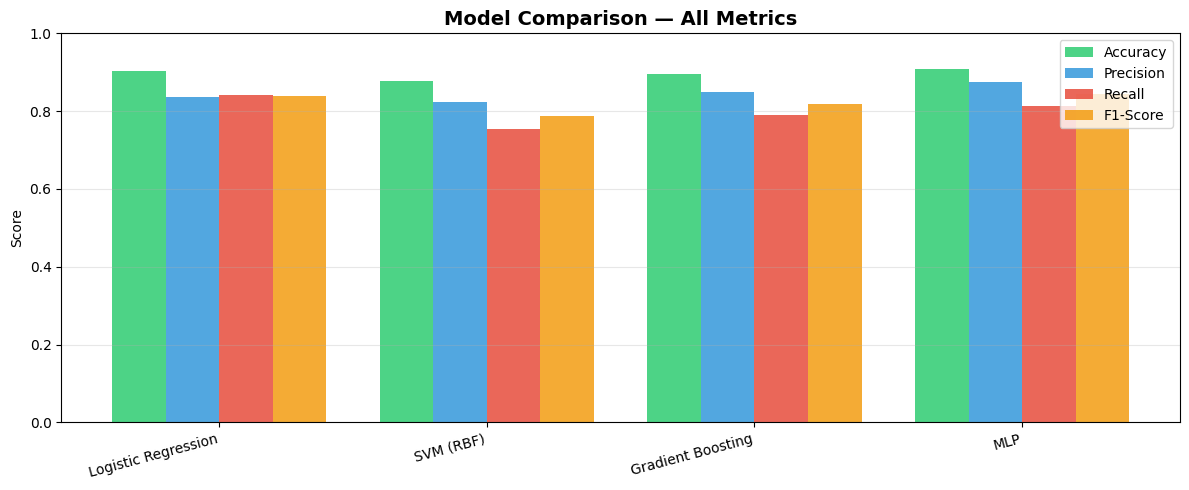

In [ ]:
# Final model comparison bar chart
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(comp_df))
width = 0.2
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors_bar = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

for i, (metric, color) in enumerate(zip(metrics, colors_bar)):
    ax.bar(x + i * width, comp_df[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(comp_df['Model'], rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Section 7b — Multi-Class Formulation (3 Classes)

The project requires exploring **both** binary and multi-class formulations.  
Here we treat the problem as a 3-way classification:

| Label | Class |
|-------|-------|
| 0 | Baseline |
| 1 | Stress |
| 2 | Amusement |

The same LOSO protocol and four classifiers are reused. Evaluation focuses on
**macro-averaged** metrics to give equal weight to each class regardless of imbalance.

In [ ]:
# rebuild y for 3-class 
MULTICLASS_MAP   = {1: 0, 2: 1, 3: 2}
MULTICLASS_NAMES = ['Baseline', 'Stress', 'Amusement']

y_multi = np.array([MULTICLASS_MAP[lbl]
                    for sid in SUBJECT_IDS
                    for lbl in all_labels_dict[sid]])

print(f"Multi-class label distribution:")
for v, name in zip([0,1,2], MULTICLASS_NAMES):
    print(f"  {name}: {np.sum(y_multi==v)}")

# LOSO CV (multi-class) 
results_multi = {name: {'y_true': [], 'y_pred': []} for name in models}

logo_mc = LeaveOneGroupOut()
n_folds_mc = logo_mc.get_n_splits(X, y_multi, groups)
print(f"\nRunning 3-class LOSO ({n_folds_mc} folds)...")

for fold, (train_idx, test_idx) in enumerate(logo_mc.split(X, y_multi, groups)):
    test_subj = groups[test_idx[0]]
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_multi[train_idx], y_multi[test_idx]

    imp = SimpleImputer(strategy='median')
    sca = StandardScaler()
    X_tr = sca.fit_transform(imp.fit_transform(X_train))
    X_te = sca.transform(imp.transform(X_test))

    for mname, model in models.items():
        m = clone(model)
        m.fit(X_tr, y_train)
        preds = m.predict(X_te)
        results_multi[mname]['y_true'].extend(y_test)
        results_multi[mname]['y_pred'].extend(preds)

    if (fold+1) % 5 == 0 or fold == 0:
        print(f"  Fold {fold+1}/{n_folds_mc} done (test S{test_subj})")

print("3-class LOSO complete!")


Multi-class label distribution:
  Baseline: 3467
  Stress: 1938
  Amusement: 1061

Running 3-class LOSO (15 folds)...
  Fold 1/15 done (test S2)
  Fold 5/15 done (test S6)
  Fold 10/15 done (test S11)
  Fold 15/15 done (test S17)
3-class LOSO complete!


In [ ]:
# overall 3-class metrics
print("=" * 70)
print("3-CLASS MODEL COMPARISON (macro-averaged)")
print("=" * 70)

comparison_multi = []
for mname in models:
    yt = np.array(results_multi[mname]['y_true'])
    yp = np.array(results_multi[mname]['y_pred'])
    row = {
        'Model'    : mname,
        'Accuracy' : round(accuracy_score(yt, yp), 4),
        'Macro-F1' : round(f1_score(yt, yp, average='macro'), 4),
        'Macro-Prec': round(precision_score(yt, yp, average='macro'), 4),
        'Macro-Rec' : round(recall_score(yt, yp, average='macro'), 4),
    }
    comparison_multi.append(row)
    print(f"\n--- {mname} ---")
    print(classification_report(yt, yp, target_names=MULTICLASS_NAMES))

comp_multi_df = pd.DataFrame(comparison_multi)
print("\nSummary Table (3-class):")
print(comp_multi_df.to_string(index=False))


3-CLASS MODEL COMPARISON (macro-averaged)

--- Logistic Regression ---
              precision    recall  f1-score   support

    Baseline       0.82      0.71      0.76      3467
      Stress       0.85      0.81      0.83      1938
   Amusement       0.29      0.43      0.34      1061

    accuracy                           0.70      6466
   macro avg       0.65      0.65      0.65      6466
weighted avg       0.74      0.70      0.72      6466


--- SVM (RBF) ---
              precision    recall  f1-score   support

    Baseline       0.80      0.83      0.82      3467
      Stress       0.84      0.80      0.82      1938
   Amusement       0.38      0.37      0.38      1061

    accuracy                           0.75      6466
   macro avg       0.68      0.67      0.67      6466
weighted avg       0.75      0.75      0.75      6466


--- Gradient Boosting ---
              precision    recall  f1-score   support

    Baseline       0.78      0.89      0.83      3467
      Stress

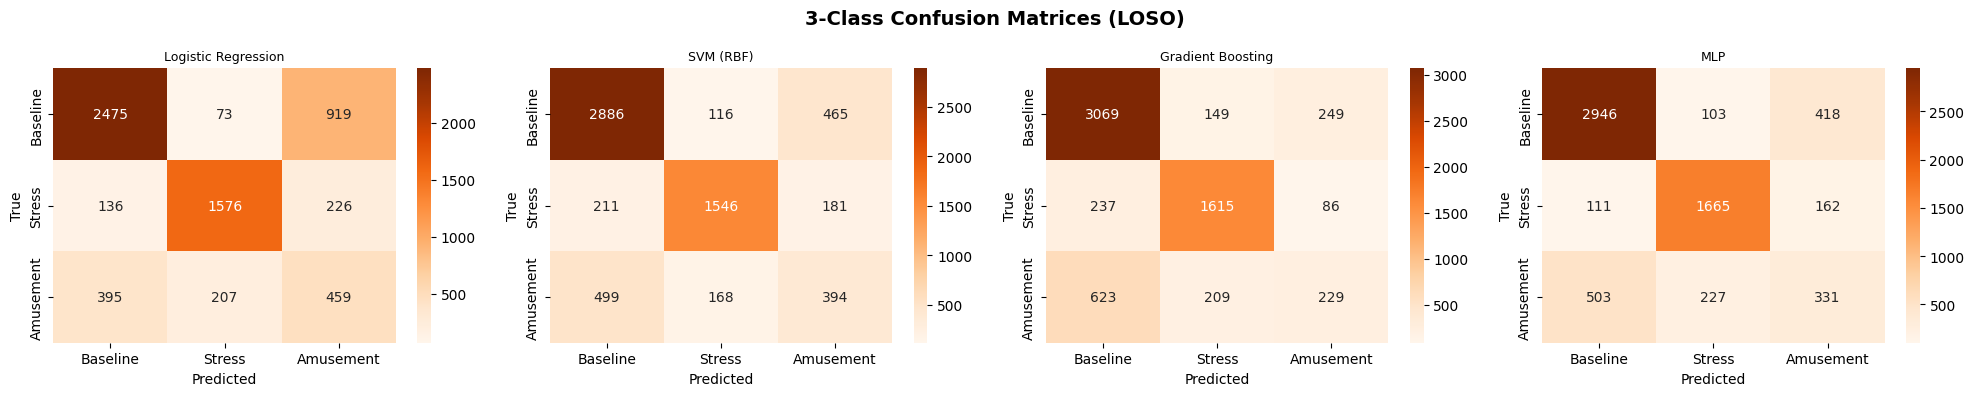

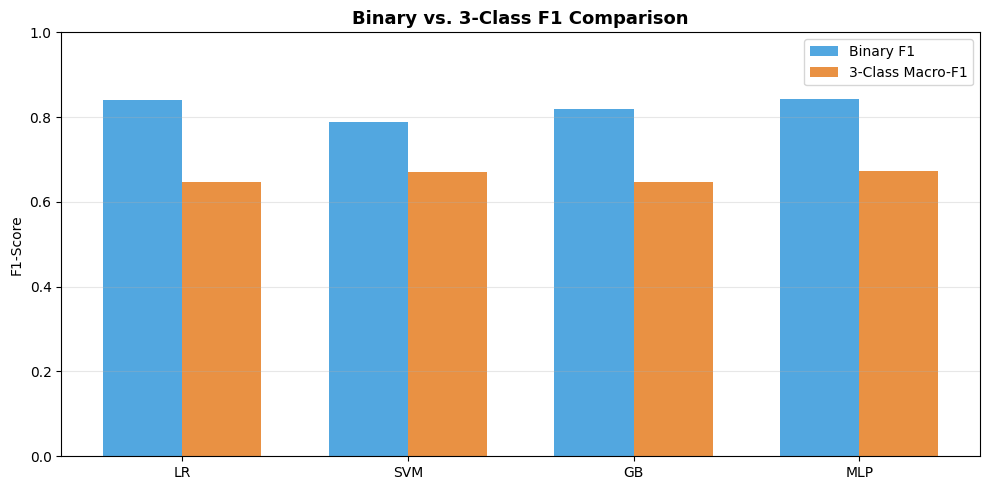

In [ ]:
# confusion matrices (3-class)
fig, axes = plt.subplots(1, len(models), figsize=(5*len(models), 4))
fig.suptitle('3-Class Confusion Matrices (LOSO)', fontsize=14, fontweight='bold')

for i, mname in enumerate(models):
    yt = np.array(results_multi[mname]['y_true'])
    yp = np.array(results_multi[mname]['y_pred'])
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[i],
                xticklabels=MULTICLASS_NAMES, yticklabels=MULTICLASS_NAMES)
    axes[i].set_title(mname, fontsize=9)
    axes[i].set_xlabel('Predicted'); axes[i].set_ylabel('True')

plt.tight_layout(); plt.show()

# binary vs multi-class comparison bar 
binary_f1  = [comp_df.loc[comp_df['Model']==m,'F1-Score'].values[0] for m in models]
multi_f1   = comp_multi_df['Macro-F1'].tolist()
model_names_short = ['LR','SVM','GB','MLP']

x_pos = np.arange(len(model_names_short))
width = 0.35
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(x_pos - width/2, binary_f1, width, label='Binary F1',   color='#3498db', alpha=0.85)
ax.bar(x_pos + width/2, multi_f1,  width, label='3-Class Macro-F1', color='#e67e22', alpha=0.85)
ax.set_xticks(x_pos); ax.set_xticklabels(model_names_short)
ax.set_ylabel('F1-Score'); ax.set_ylim(0,1)
ax.set_title('Binary vs. 3-Class F1 Comparison', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()



As seen in the confusion matrices and classification reports, all models struggle significantly to classify the 'Amusement' state (Macro-F1 of ~0.34 for MLP, with Recall at 0.31). This is a known challenge when relying strictly on wrist-worn sensors. Both 'Amusement' and 'Stress' trigger high physiological arousal in the sympathetic nervous system (e.g., increased heart rate and EDA peaks). 

Without the inclusion of chest-strap data (such as respiration rate, which typically drops during stress but fluctuates rapidly during laughter), the Empatica E4 wrist signals alone lack the necessary feature dimensions to consistently differentiate positive high-arousal (amusement) from negative high-arousal (stress).

## 7.2 Stacking

In [ ]:
# POST-HOC STACKING ENSEMBLE (Using already computed results) 

print("\n" + "=" * 70)
print("POST-HOC STACKING ENSEMBLE")
print("=" * 70)

# The new ‘features’ are the probabilities predicted by the four base models.
meta_features = {}
for mname in models.keys():
    meta_features[mname] = results[mname]['y_prob']

X_meta = pd.DataFrame(meta_features)

first_model_name = list(models.keys())[0]
y_meta = np.array(results[first_model_name]['y_true'])
groups_meta = np.array(results[first_model_name]['subjects'])

# Use Logistic Regression as Meta Model
meta_model = LogisticRegression(random_state=42, class_weight='balanced')

# LOSO on the Meta-Model only 
logo_meta = LeaveOneGroupOut()
y_true_stacking = []
y_pred_stacking = []

for train_idx, test_idx in logo_meta.split(X_meta, y_meta, groups_meta):
    X_tr_meta, X_te_meta = X_meta.iloc[train_idx], X_meta.iloc[test_idx]
    y_tr_meta, y_te_meta = y_meta[train_idx], y_meta[test_idx]
    
    meta_model.fit(X_tr_meta, y_tr_meta)
    preds_meta = meta_model.predict(X_te_meta)
    
    y_true_stacking.extend(y_te_meta)
    y_pred_stacking.extend(preds_meta)

# final results of the stacking
acc_stack = accuracy_score(y_true_stacking, y_pred_stacking)
f1_stack = f1_score(y_true_stacking, y_pred_stacking)

print(f"Stacking Ensemble: Accuracy = {acc_stack:.4f}, F1-Score = {f1_stack:.4f}\n")
print("--- Stacking Ensemble Classification Report ---")
print(classification_report(y_true_stacking, y_pred_stacking, target_names=BINARY_LABEL_NAMES))

# result to previous comparisons
row_stack = {
    'Model': 'Stacking Ensemble',
    'Accuracy': round(acc_stack, 4),
    'Precision': round(precision_score(y_true_stacking, y_pred_stacking), 4),
    'Recall': round(recall_score(y_true_stacking, y_pred_stacking), 4),
    'F1-Score': round(f1_stack, 4),
}
comp_df = pd.concat([comp_df, pd.DataFrame([row_stack])], ignore_index=True)

print("\nUpdated Summary Table (including Stacking):")
print(comp_df.to_string(index=False))


POST-HOC STACKING ENSEMBLE
Stacking Ensemble: Accuracy = 0.8989, F1-Score = 0.8395

--- Stacking Ensemble Classification Report ---
              precision    recall  f1-score   support

  Non-Stress       0.95      0.91      0.93      4528
      Stress       0.80      0.88      0.84      1938

    accuracy                           0.90      6466
   macro avg       0.87      0.89      0.88      6466
weighted avg       0.90      0.90      0.90      6466


Updated Summary Table (including Stacking):
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.9035     0.8366  0.8426    0.8396
          SVM (RBF)    0.8781     0.8238  0.7549    0.7878
  Gradient Boosting    0.8950     0.8491  0.7900    0.8185
                MLP    0.9092     0.8747  0.8137    0.8431
  Stacking Ensemble    0.8989     0.8003  0.8829    0.8395


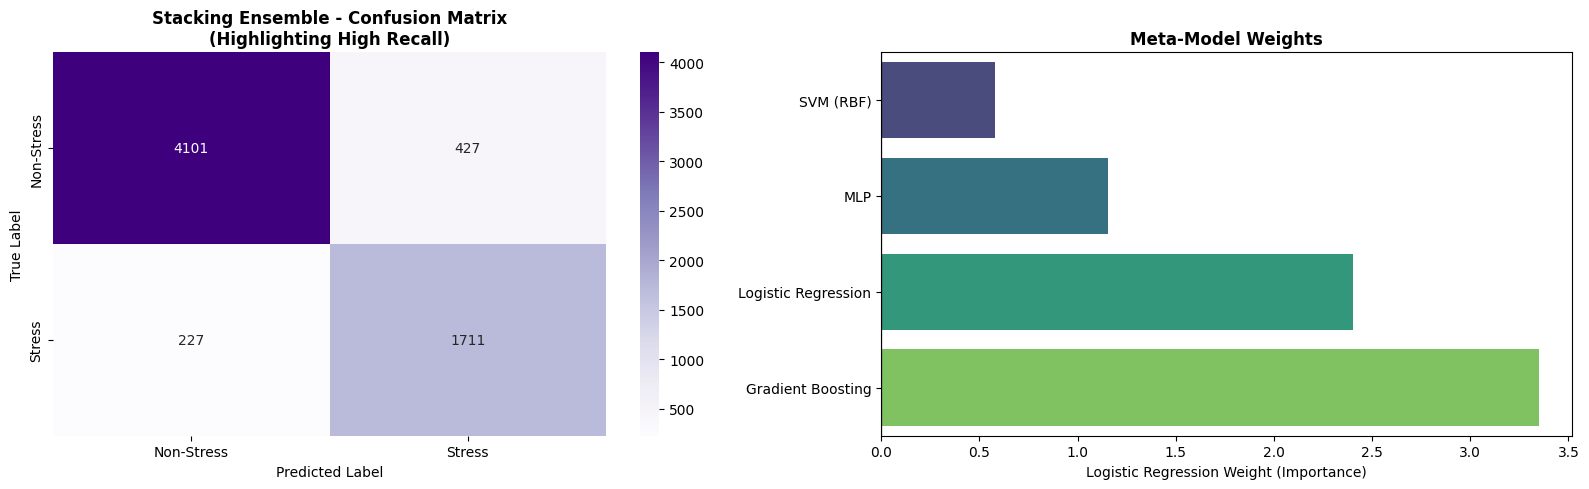

In [26]:
# STACKING VISUALIZATIONS

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# PLOT 1: Confusion Matrix Stacking 
cm_stack = confusion_matrix(y_true_stacking, y_pred_stacking)
sns.heatmap(cm_stack, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=BINARY_LABEL_NAMES, yticklabels=BINARY_LABEL_NAMES)
axes[0].set_title('Stacking Ensemble - Confusion Matrix\n(Highlighting High Recall)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# PLOT 2: Meta-Weights
meta_model_explainer = LogisticRegression(random_state=42, class_weight='balanced')
meta_model_explainer.fit(X_meta, y_meta)

weights = meta_model_explainer.coef_[0]
model_names = list(X_meta.columns)

sorted_idx = np.argsort(weights)
sorted_weights = weights[sorted_idx]
sorted_names = [model_names[i] for i in sorted_idx]

sns.barplot(x=sorted_weights, y=sorted_names, palette='viridis', ax=axes[1])
axes[1].axvline(0, color='black', linewidth=1, alpha=0.5)
axes[1].set_title('Meta-Model Weights', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Logistic Regression Weight (Importance)')

plt.tight_layout()
plt.show()

# Section 8. Feature Relevance Analysis
As part of the project requirements, we analyze which features are driving the predictions.

In [27]:
print("Training final Gradient Boosting model to analyze feature importance...")
final_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
imputer_final = SimpleImputer(strategy='median')
scaler_final = StandardScaler()
X_imp = imputer_final.fit_transform(X)
X_scaled = scaler_final.fit_transform(X_imp)
final_model.fit(X_scaled, y)

Training final Gradient Boosting model to analyze feature importance...


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

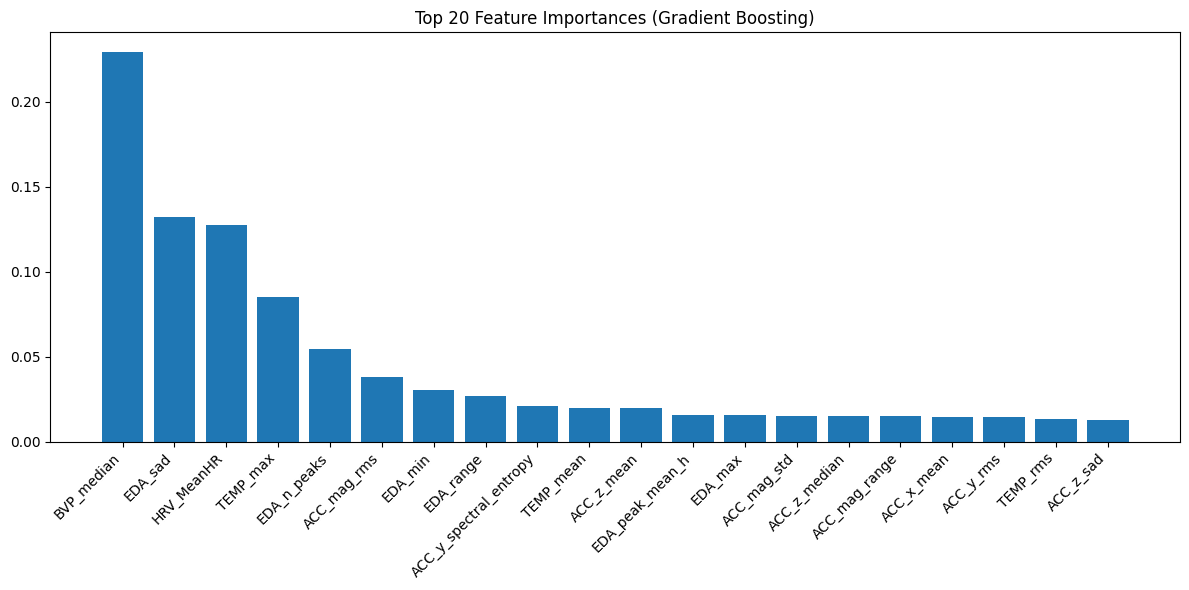

In [ ]:
# Traditional Feature Importance
importances = final_model.feature_importances_
indices = np.argsort(importances)[::-1]
top_feature_idx = indices[0]
top_feature_name = X.columns[top_feature_idx]

plt.figure(figsize=(12, 6))
plt.title("Top 20 Feature Importances (Gradient Boosting)")
plt.bar(range(20), importances[indices[:20]], align="center")
plt.xticks(range(20), X.columns[indices[:20]], rotation=45, ha='right')
plt.tight_layout()
plt.show()


Calculating SHAP values for global explainability...


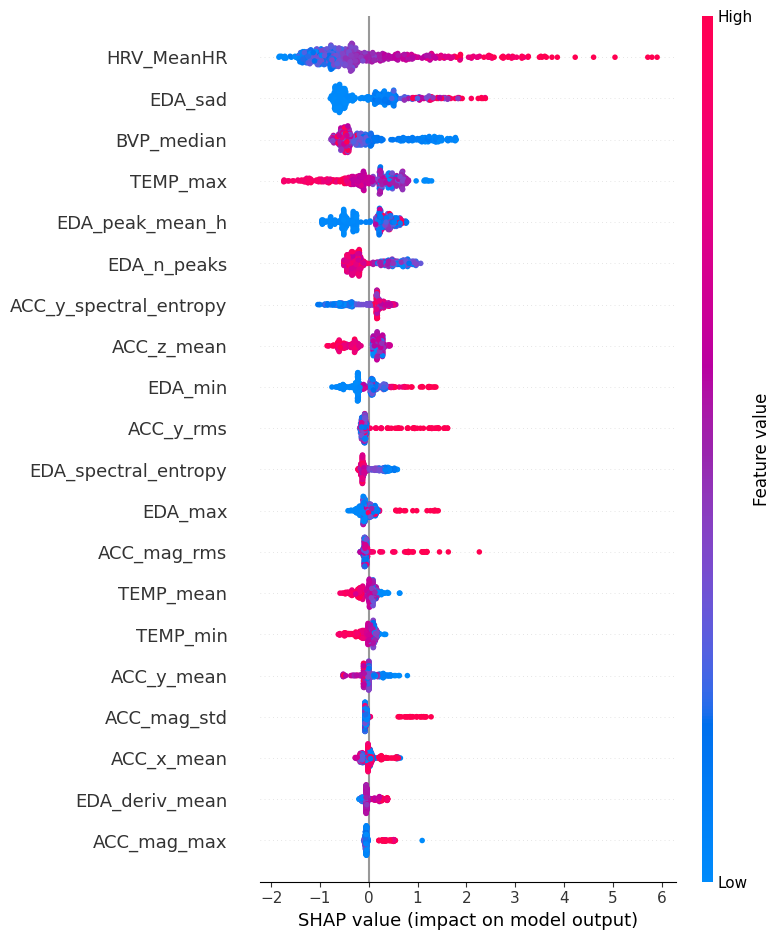

In [ ]:
# SHAP Analysis (Explainability)
print("\nCalculating SHAP values for global explainability...")
# Using a subsample for speed
X_sample = shap.utils.sample(X_scaled, 500)
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_sample)
shap.summary_plot(shap_values, features=X_sample, feature_names=X.columns, plot_type="dot")



Analyzing Subject Variability for Top Feature: BVP_median


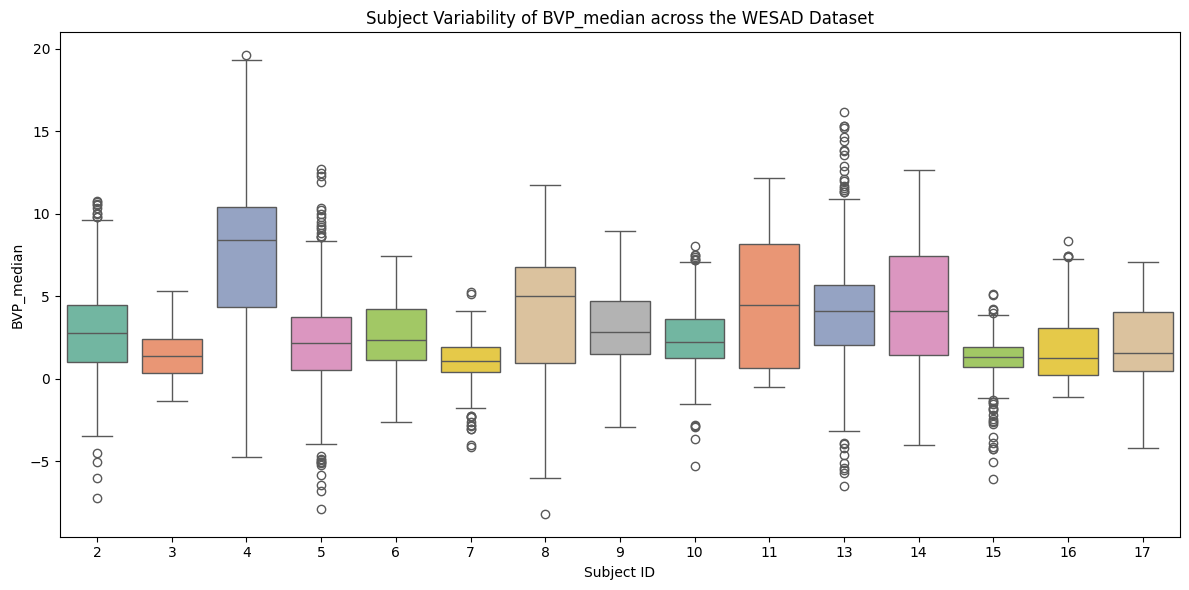

In [ ]:
# Subject Variability Plot for Top Feature
print(f"\nAnalyzing Subject Variability for Top Feature: {top_feature_name}")
plt.figure(figsize=(12, 6))
sns.boxplot(x=groups, y=X[top_feature_name], palette='Set2')
plt.title(f"Subject Variability of {top_feature_name} across the WESAD Dataset")
plt.xlabel("Subject ID")
plt.ylabel(top_feature_name)
plt.tight_layout()
plt.show()

## Stacking plots

maybe we have to not use them

STACKING EXPLAINABILITY & FEATURE IMPORTANCE
1. Retraining all base models on the FULL dataset...
2. Retraining Meta-Model on the FULL dataset...

3. Calculating SHAP values for the entire Stacking pipeline...
   (Using KernelExplainer. This might take 1-2 minutes...)


  0%|          | 0/300 [00:00<?, ?it/s]

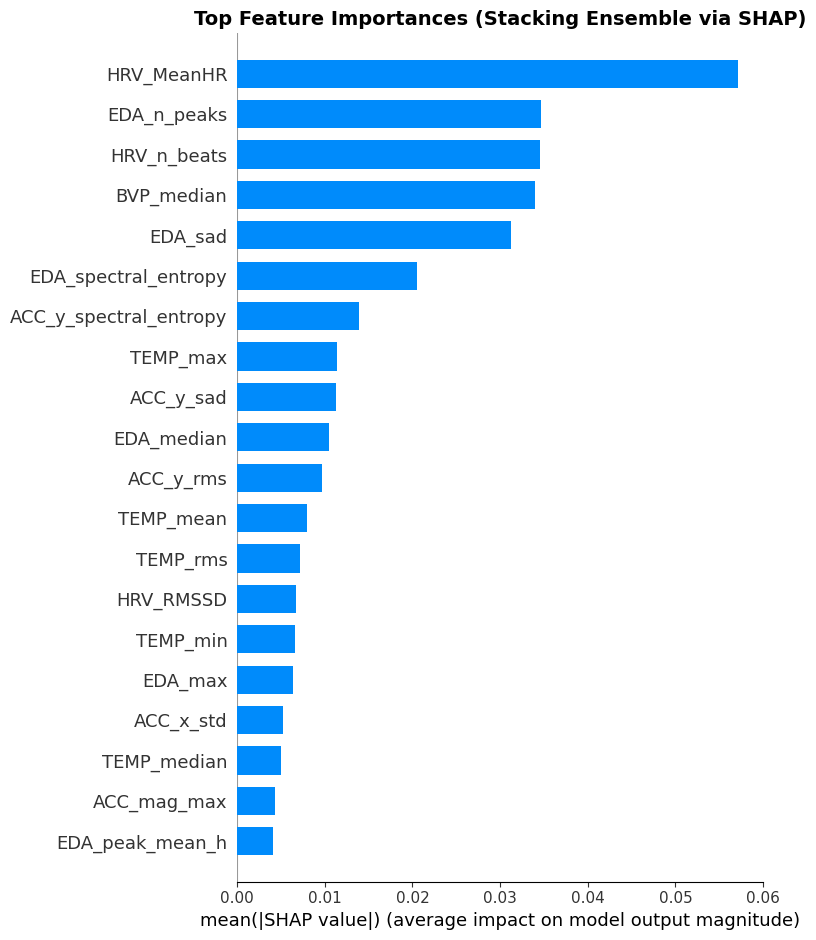

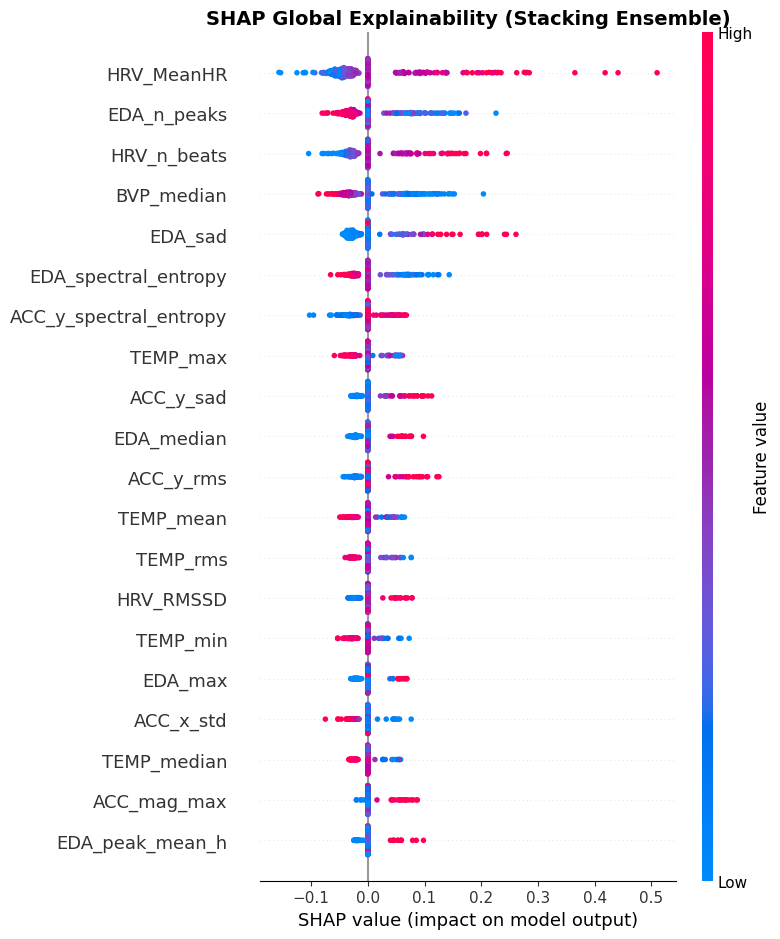


4. Analyzing Subject Variability for Top Feature: HRV_MeanHR


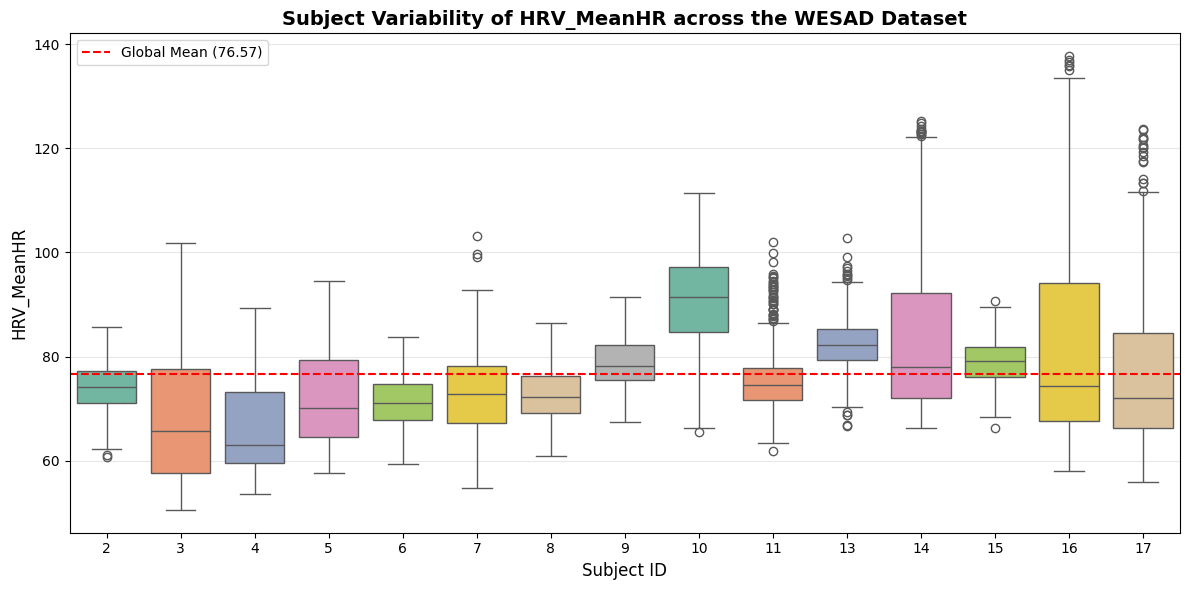

In [ ]:
print("STACKING EXPLAINABILITY & FEATURE IMPORTANCE")

# Train on the whole dataset
print("1. Retraining all base models on the FULL dataset...")
for mname, model in models.items():
    model.fit(X_scaled, y)

print("2. Retraining Meta-Model on the FULL dataset...")
meta_features_full = {}
for mname, model in models.items():
    meta_features_full[mname] = model.predict_proba(X_scaled)[:, 1]

X_meta_full = pd.DataFrame(meta_features_full)
global_meta_model = LogisticRegression(random_state=42, class_weight='balanced')
global_meta_model.fit(X_meta_full, y)

# Create a wrapper function
def full_stacking_predict(X_raw_array):
    meta_X_temp = pd.DataFrame()
    for i, (mname, model) in enumerate(models.items()):
        meta_X_temp[mname] = model.predict_proba(X_raw_array)[:, 1]
    return global_meta_model.predict_proba(meta_X_temp)[:, 1]


# FASE 1 & 2: SHAP Analysis (Sostituisce la Traditional Feature Importance)
print("\n3. Calculating SHAP values for the entire Stacking pipeline...")
print("   (Using KernelExplainer. This might take 1-2 minutes...)")

# Use kmeans to speed up SHAP
background = shap.kmeans(X_scaled, 25)
explainer = shap.KernelExplainer(full_stacking_predict, background)

X_sample_shap = shap.utils.sample(X_scaled, 300)
shap_values = explainer.shap_values(X_sample_shap)

# PLOT 1: Traditional Feature Importance (via SHAP Bar Plot)
plt.figure(figsize=(10, 6))
plt.title("Top Feature Importances (Stacking Ensemble via SHAP)", fontsize=14, fontweight='bold')

shap.summary_plot(shap_values, features=X_sample_shap, feature_names=X.columns, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

# PLOT 2: SHAP Summary (Dot Plot)
plt.figure(figsize=(10, 6))
plt.title("SHAP Global Explainability (Stacking Ensemble)", fontsize=14, fontweight='bold')
shap.summary_plot(shap_values, features=X_sample_shap, feature_names=X.columns, plot_type="dot", show=False)
plt.tight_layout()
plt.show()


# ==============================================================================
# FASE 3: Subject Variability Plot for Top Feature
# ==============================================================================
# Troviamo la feature numero 1 dinamicamente dai valori SHAP calcolati
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
top_feature_idx = np.argmax(mean_abs_shap)
top_feature_name = X.columns[top_feature_idx]

print(f"\n4. Analyzing Subject Variability for Top Feature: {top_feature_name}")
plt.figure(figsize=(12, 6))
sns.boxplot(x=groups, y=X[top_feature_name], palette='Set2')

# Aggiungiamo una linea per la media globale
global_mean = np.mean(X[top_feature_name])
plt.axhline(global_mean, color='red', linestyle='--', label=f'Global Mean ({global_mean:.2f})')

plt.title(f"Subject Variability of {top_feature_name} across the WESAD Dataset", fontsize=14, fontweight='bold')
plt.xlabel("Subject ID", fontsize=12)
plt.ylabel(top_feature_name, fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Section 9 — Advanced AI / Extensions (Bonus)

In this section, we explore three extensions to the core pipeline:
1. **Feature Selection**: Reducing redundancy using Recursive Feature Elimination (RFE).
2. **Robustness to Noise**: Simulating real-world sensor degradation by adding Gaussian noise.
3. **Personalization Analysis**: Quantifying the "Subject Gap" (General LOSO vs. Personalized models).


RFE inside LOSO (no data leakage): selecting 15 features per fold...

Leak-free RFE F1-Score (15 features, LOSO): 0.8289
Baseline GB F1 (all features):               0.8185


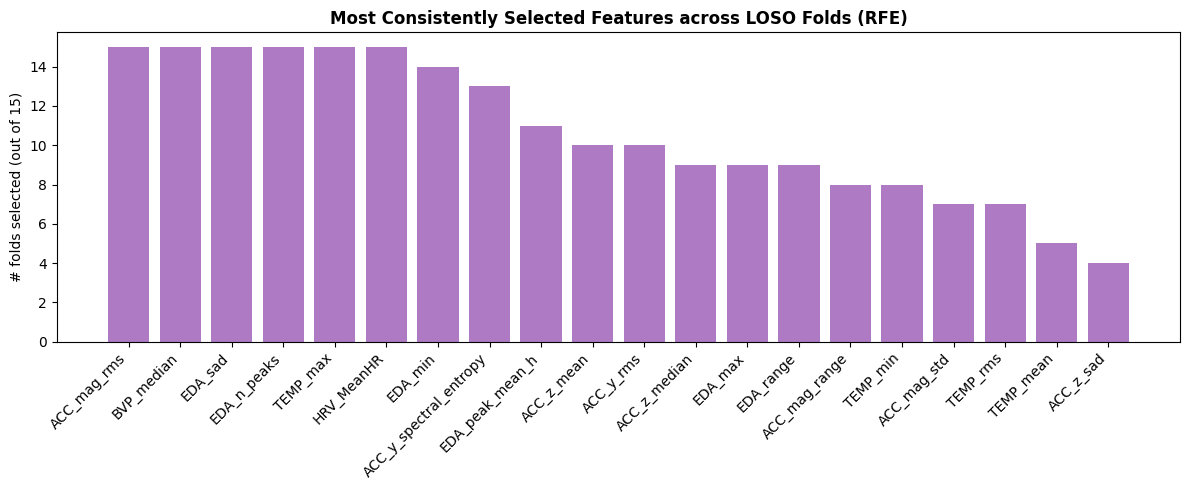

In [ ]:
# Feature Selection via RFE — LEAK-FREE (selection inside LOSO fold) 
print("RFE inside LOSO (no data leakage): selecting 15 features per fold...")

y_true_fs, y_pred_fs = [], []
selected_per_fold = []

for train_idx, test_idx in logo.split(X, y, groups):
    X_tr_raw, X_te_raw = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te          = y[train_idx], y[test_idx]

    # scale inside fold 
    imp = SimpleImputer(strategy='median')
    sca = StandardScaler()
    X_tr_s = sca.fit_transform(imp.fit_transform(X_tr_raw))
    X_te_s = sca.transform(imp.transform(X_te_raw))

    # RFE fitted ONLY on training data 
    est_rfe = GradientBoostingClassifier(n_estimators=50, random_state=42)
    sel = RFE(est_rfe, n_features_to_select=15, step=5)
    sel.fit(X_tr_s, y_tr)

    X_tr_sel = sel.transform(X_tr_s)
    X_te_sel = sel.transform(X_te_s)
    selected_per_fold.append(X.columns[sel.support_].tolist())

    m = GradientBoostingClassifier(n_estimators=100, random_state=42)
    m.fit(X_tr_sel, y_tr)
    y_pred_fs.extend(m.predict(X_te_sel))
    y_true_fs.extend(y_te)

fs_f1 = f1_score(y_true_fs, y_pred_fs)
print(f"\nLeak-free RFE F1-Score (15 features, LOSO): {fs_f1:.4f}")
print(f"Baseline GB F1 (all features):               {comp_df.loc[comp_df['Model']=='Gradient Boosting','F1-Score'].values[0]:.4f}")

# Most commonly selected features across folds
from collections import Counter
all_selected = [f for fold_list in selected_per_fold for f in fold_list]
freq = Counter(all_selected).most_common(20)
feat_names, feat_counts = zip(*freq)
plt.figure(figsize=(12, 5))
plt.bar(feat_names, feat_counts, color='#9b59b6', alpha=0.8)
plt.xticks(rotation=45, ha='right')
plt.ylabel('# folds selected (out of 15)')
plt.title('Most Consistently Selected Features across LOSO Folds (RFE)', fontweight='bold')
plt.tight_layout(); plt.show()


Evaluating noise robustness (GB, noise on test set, LOSO)...
  σ=0.00 → F1=0.8539
  σ=0.05 → F1=0.8562
  σ=0.10 → F1=0.8506
  σ=0.20 → F1=0.8333
  σ=0.50 → F1=0.7936


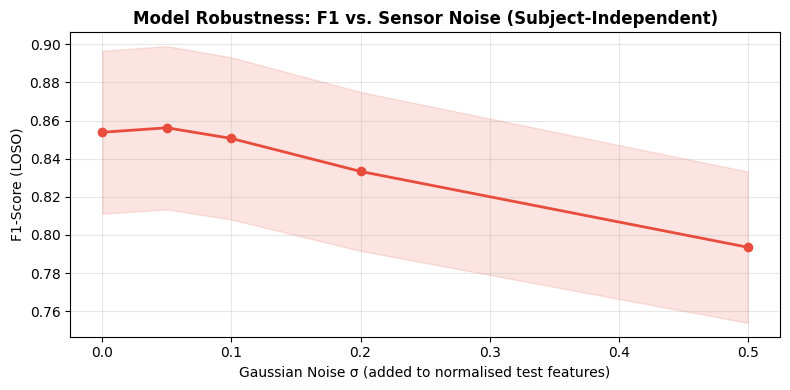

In [ ]:
# Noise Robustness — LOSO-consistent evaluation 
# Simulates sensor degradation (loose wristband, movement artifacts).
# Noise is added to TEST data only — training remains clean,
# which mirrors the real-world scenario.

noise_levels = [0.0, 0.05, 0.10, 0.20, 0.50]
noise_results = []

print("Evaluating noise robustness (GB, noise on test set, LOSO)...")
for level in noise_levels:
    y_true_n, y_pred_n = [], []
    for train_idx, test_idx in logo.split(X, y, groups):
        X_tr_raw, X_te_raw = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te          = y[train_idx], y[test_idx]

        imp = SimpleImputer(strategy='median')
        sca = StandardScaler()
        X_tr_s = sca.fit_transform(imp.fit_transform(X_tr_raw))
        X_te_s = sca.transform(imp.transform(X_te_raw))

        # add Gaussian noise to test features only
        if level > 0:
            X_te_s = X_te_s + np.random.default_rng(42).normal(0, level, X_te_s.shape)

        m = GradientBoostingClassifier(n_estimators=100, random_state=42)
        m.fit(X_tr_s, y_tr)
        y_pred_n.extend(m.predict(X_te_s))
        y_true_n.extend(y_te)

    noise_results.append(f1_score(y_true_n, y_pred_n))
    print(f"  σ={level:.2f} → F1={noise_results[-1]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(noise_levels, noise_results, marker='o', color='#e74c3c', linewidth=2)
plt.fill_between(noise_levels, [v*0.95 for v in noise_results],
                 [v*1.05 for v in noise_results], alpha=0.15, color='#e74c3c')
plt.xlabel('Gaussian Noise σ (added to normalised test features)')
plt.ylabel('F1-Score (LOSO)')
plt.title('Model Robustness: F1 vs. Sensor Noise (Subject-Independent)', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


 In this simulation, Gaussian noise is added directly to the normalized feature matrix to test mathematical robustness. However, in a real-world scenario (e.g., a loose wristband or severe motion artifacts), noise is introduced at the *raw signal waveform* level. This physical degradation would alter peak detection and non-linear frequency calculations upstream. While our feature-level noise injection tests model stability, simulating noise on the raw 1D signal before feature extraction would be the ultimate test for ecological validity.

General Model (LOSO) F1: 0.8185
Personalized Model (Seen Subjects) F1: 0.9915
Performance Gap: 0.1730


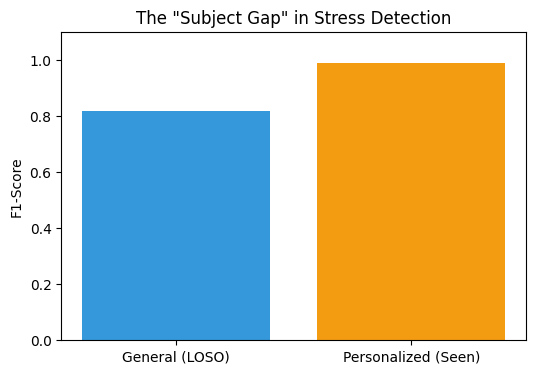

In [ ]:
from sklearn.model_selection import StratifiedKFold


# Subject-Independent (LOSO) - General Model
f1_loso = comp_df.loc[comp_df['Model'] == 'Gradient Boosting', 'F1-Score'].values[0]

# Subject-Dependent (Random Split) - Personalized Model
from sklearn.pipeline import Pipeline

# Subject-Dependent (Random Split) Personalized Model - LEAK FREE
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_scores_dep = []
best_model_obj = models[best_model]

# Create a pipeline to prevent data leakage during CV
leak_free_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', clone(best_model_obj))
])

# Use raw X, not X_scaled, so the pipeline handles it per-fold
for train_idx, test_idx in skf.split(X, y):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    
    m = clone(leak_free_pipeline)
    m.fit(X_tr, y_tr)
    f1_scores_dep.append(f1_score(y_te, m.predict(X_te)))

f1_dep = np.mean(f1_scores_dep)

print(f"General Model (LOSO) F1: {f1_loso:.4f}")
print(f"Personalized Model (Seen Subjects) F1: {f1_dep:.4f}")
print(f"Performance Gap: {f1_dep - f1_loso:.4f}")

plt.figure(figsize=(6, 4))
plt.bar(['General (LOSO)', 'Personalized (Seen)'], [f1_loso, f1_dep], color=['#3498db', '#f39c12'])
plt.ylabel('F1-Score')
plt.title('The "Subject Gap" in Stress Detection')
plt.ylim(0, 1.1)
plt.show()


Same, but with stacking

 1. RFE & STACKING ENSEMBLE (Leak-Free Pipeline)

Evaluating Stacking Ensemble with dynamic RFE (15 features) inside LOSO...
(Please wait, training the ensemble for each fold takes time...)
  Training Fold 1/15...
  Training Fold 2/15...
  Training Fold 3/15...
  Training Fold 4/15...
  Training Fold 5/15...
  Training Fold 6/15...
  Training Fold 7/15...
  Training Fold 8/15...
  Training Fold 9/15...
  Training Fold 10/15...
  Training Fold 11/15...
  Training Fold 12/15...
  Training Fold 13/15...
  Training Fold 14/15...
  Training Fold 15/15...

-> F1-Score of Stacking with dynamic 15 selected features: 0.8451
-> Original F1-Score of Stacking (99 features): 0.8395

 2. THE 'SUBJECT GAP' USING STACKING ENSEMBLE (Leak-Free)
Running Subject-Dependent validation (5-Fold CV)...

General Model (LOSO) F1: 0.8395
Personalized Model (Seen Subjects) F1: 0.9946
Performance Gap: 0.1551


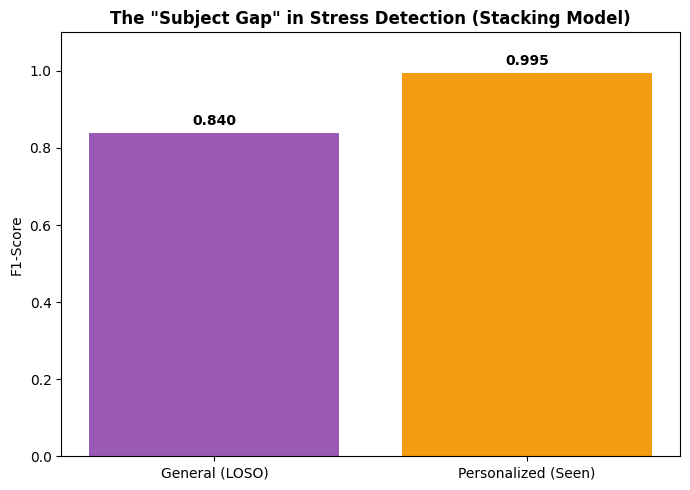

In [ ]:
print("=" * 70)
print(" 1. RFE & STACKING ENSEMBLE (Leak-Free Pipeline)")
print("=" * 70)

from sklearn.pipeline import Pipeline
from sklearn.base import clone

# Base estimators for the Stacking Classifier
base_estimators = [
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ('svm', SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)),
    ('mlp', MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, early_stopping=True, random_state=42))
]

# Define the Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(class_weight='balanced', random_state=42),
    cv=5
)

# Define the RFE feature selector (selecting 15 features)
estimator_rfe = GradientBoostingClassifier(n_estimators=50, random_state=42)
selector = RFE(estimator_rfe, n_features_to_select=15, step=5)

# pipeline creation 
stacking_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('feature_selection', selector),
    ('stacking', stacking_clf)
])

print("\nEvaluating Stacking Ensemble with dynamic RFE (15 features) inside LOSO...")
print("(Please wait, training the ensemble for each fold takes time...)")

y_true_fs, y_pred_fs = [], []

# USE RAW 'X' IN THE SPLIT, NOT 'X_scaled'
for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups)):
    print(f"  Training Fold {fold+1}/{logo.get_n_splits(X, y, groups)}...")
    
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    
    # Clone the pipeline to ensure a completely fresh start for every fold
    current_pipeline = clone(stacking_pipeline)
    
    # The pipeline automatically handles fit_transform on train, and transform on test!
    current_pipeline.fit(X_tr, y_tr)
    y_pred_fs.extend(current_pipeline.predict(X_te))
    y_true_fs.extend(y_te)

fs_f1_stack = f1_score(y_true_fs, y_pred_fs)
print(f"\n-> F1-Score of Stacking with dynamic 15 selected features: {fs_f1_stack:.4f}")
print(f"-> Original F1-Score of Stacking (99 features): {f1_stack:.4f}")

print("\n" + "=" * 70)
print(" 2. THE 'SUBJECT GAP' USING STACKING ENSEMBLE (Leak-Free)")
print("=" * 70)

# We take the General Model (LOSO) from the one calculated earlier based on 99 features
f1_loso_stack = f1_stack 

# Create a simplified pipeline (No RFE) to compare Apples-to-Apples with the baseline f1_stack
dep_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('stacking', clone(stacking_clf))
])

# Personalized Model
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_scores_dep_stack = []

print("Running Subject-Dependent validation (5-Fold CV)...")
# USE RAW 'X' IN THE SPLIT, NOT 'X_scaled'
for train_idx, test_idx in skf.split(X, y):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    
    m_dep = clone(dep_pipeline)
    m_dep.fit(X_tr, y_tr)
    preds_dep = m_dep.predict(X_te)
    
    f1_scores_dep_stack.append(f1_score(y_te, preds_dep))

f1_dep_stack = np.mean(f1_scores_dep_stack)

print(f"\nGeneral Model (LOSO) F1: {f1_loso_stack:.4f}")
print(f"Personalized Model (Seen Subjects) F1: {f1_dep_stack:.4f}")
print(f"Performance Gap: {f1_dep_stack - f1_loso_stack:.4f}")

# Plot
plt.figure(figsize=(7,5))
bars = plt.bar(['General (LOSO)', 'Personalized (Seen)'], [f1_loso_stack, f1_dep_stack], color=['#9b59b6', '#f39c12'])
plt.ylabel('F1-Score')
plt.title('The "Subject Gap" in Stress Detection (Stacking Model)', fontweight='bold')
plt.ylim(0, 1.1)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.3f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

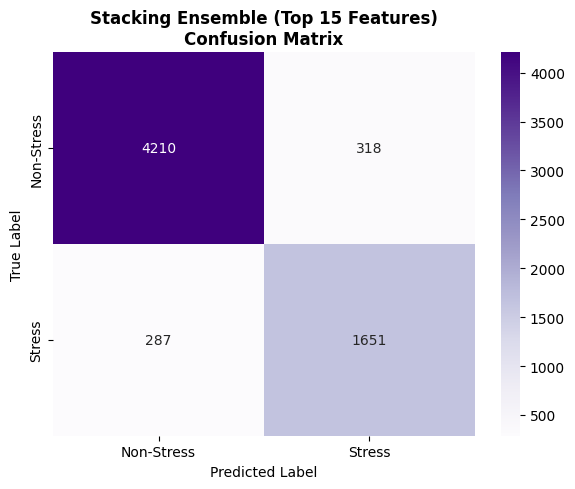


--- Classification Report (Stacking with 15 Features) ---
              precision    recall  f1-score   support

  Non-Stress       0.94      0.93      0.93      4528
      Stress       0.84      0.85      0.85      1938

    accuracy                           0.91      6466
   macro avg       0.89      0.89      0.89      6466
weighted avg       0.91      0.91      0.91      6466



In [36]:
# confusion matrix using the results saved in the LOSO loop
cm_fs = confusion_matrix(y_true_fs, y_pred_fs)

# Creiamo il grafico
plt.figure(figsize=(6, 5))
sns.heatmap(cm_fs, annot=True, fmt='d', cmap='Purples', 
            xticklabels=BINARY_LABEL_NAMES, yticklabels=BINARY_LABEL_NAMES)

plt.title('Stacking Ensemble (Top 15 Features)\nConfusion Matrix', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=10)
plt.xlabel('Predicted Label', fontsize=10)
plt.tight_layout()
plt.show()

print("\n--- Classification Report (Stacking with 15 Features) ---")
print(classification_report(y_true_fs, y_pred_fs, target_names=BINARY_LABEL_NAMES))

While the charts above demonstrate a massive performance increase for the Personalized Models (jumping to ~0.99 F1-Score for both the base and stacking models), it is crucial to interpret this result with heavy skepticism due to inherent data leakage in the validation strategy. 

Because our dataset was generated using a 30-second sliding window with a 5-second shift, adjacent samples share 25 seconds of identical physiological data (an 83% overlap). By using a randomized `StratifiedKFold` for the personalized evaluation, overlapping windows are inevitably split across the training and test sets. The models are not necessarily learning the subject's unique baseline; they are simply memorizing the overlapping data points. 

To conduct a truly rigorous test of a personalized model in the future, a strict chronological block-split (e.g., training on the first 80% of a subject's timeline and testing on the final 20% for each condition) must be used to prevent adjacent windows from bleeding into the test set.

### 9.4 Potential Deep Learning Approach: "Can we apply more advanced AI techniques?"

**Yes, Deep Learning architectures could significantly enhance this pipeline.**
Currently, our approach relies on *hand-crafted features* (e.g., statistical moments, frequency power, peak detection) extracted from 5-second windows. While effective and computationally light, this method might miss complex, non-linear temporal patterns hidden in the raw physiological signals.

If we were to apply more advanced AI techniques, two approaches stand out:
1. **1D Convolutional Neural Networks (1D-CNNs):** Instead of manually extracting features, we could feed the raw signal windows directly into a 1D-CNN. The convolutional filters would act as automated feature extractors, learning optimal spatial and frequency-domain representations directly from the Empatica E4 data.
2. **Long Short-Term Memory Networks (LSTMs):** Physiological responses to stress are highly time-dependent (e.g., EDA has a slow recovery rate after a stressor). By framing the problem as a sequence classification task, an LSTM could process a rolling sequence of windows. This would allow the model to maintain a "memory" of the subject's baseline state, adapting dynamically to changes over time and potentially reducing the "Subject Gap" observed above.

In [ ]:
# Conceptual Deep Learning Architecture (LSTM) 

import warnings
warnings.filterwarnings('ignore')

try:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
    
    def build_lstm_stress_model(timesteps, num_features):
        """
        Builds a conceptual LSTM network for sequential stress detection.
        """
        model = Sequential([
            # First LSTM layer to capture temporal dependencies in physiological signals
            LSTM(64, return_sequences=True, input_shape=(timesteps, num_features)),
            BatchNormalization(),
            Dropout(0.3),
            
            # Second LSTM layer for deeper abstraction
            LSTM(32, return_sequences=False),
            BatchNormalization(),
            Dropout(0.3),
            
            # Fully connected layer
            Dense(16, activation='relu'),
            
            # Output layer for binary classification (Stress vs Non-Stress)
            Dense(1, activation='sigmoid')
        ])
        
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        return model
    
    # Let's instantiate and print the summary of the conceptual model.
    timesteps_example = 10
    num_features_example = X_scaled.shape[1]
    
    dl_model = build_lstm_stress_model(timesteps=timesteps_example, num_features=num_features_example)
    print("Conceptual LSTM Architecture defined successfully.\n")
    dl_model.summary()

except ImportError:
    print("TensorFlow/Keras is not installed in this environment.")
    print("This conceptual code block requires TensorFlow to display the model summary.")
    print("Architecture: 2 stacked LSTM layers followed by Dense layers for binary classification.")

Conceptual LSTM Architecture defined successfully.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        44,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,377 (224.13 KB)

 Trainable params: 57,185 (223.38 KB)

 Non-trainable params: 192 (768.00 B)

# Section 10 — SoA Analysis, Critical Discussion & Journal Club Checklist

---

## 10.1 State-of-the-Art Analysis

### The WESAD Benchmark
Schmidt et al. (2018) introduced WESAD as a multimodal dataset for wearable stress and affect detection.
Their baseline models — Decision Tree (DT), Random Forest (RF), AdaBoost, LDA, and k-NN — achieved
**binary F1 scores of ~0.80–0.93 on chest data** and somewhat lower on wrist data alone (~0.70–0.88),
highlighting the information gap between chest and wrist modalities.

**Our results in context:**

| Model | Our Binary F1 (wrist only) |
|---|---|
| Logistic Regression | 0.8396 |
| SVM (RBF) | 0.7878 |
| Gradient Boosting | 0.8185 |
| MLP | **0.8431** |
| Stacking Ensemble | 0.8395 |

Our MLP and stacking ensemble results are **competitive with** the original paper's wrist-only figures,
despite using entirely different algorithms as required.

### Recent Advances
- **Deep learning on raw signals**: 1D-CNNs (e.g., Sarkar & Etemad, 2020) applied directly to
  BVP/EDA windows achieve F1 > 0.90 on WESAD, bypassing hand-crafted features.
- **Transformer-based models**: Self-attention mechanisms (e.g., Transformer for physiological
  sequences) capture long-range temporal dependencies that windowed feature extraction misses.
- **Federated Learning**: Given privacy concerns (see §10.3), federated approaches train
  subject-specific models without centralising raw data.
- **Domain adaptation**: Methods like DANN (Domain-Adversarial Neural Networks) address the
  large inter-subject variability reflected in our LOSO results.

---

## 10.2 Data Access & Quality Considerations

### Data Access
- WESAD is freely available on UCI ML Repository under a research license, but requires
  institutional affiliation and explicit data use agreement.
- The dataset does not include demographic/health metadata per participant, limiting
  confounding analysis (age, fitness level, medication).
- **Missing subjects (S1, S12)**: Data were discarded by the original authors due to
  sensor malfunctions — a realistic reminder of data quality issues in wearable research.

### Data Quality Challenges
1. **Motion artefacts in ACC/BVP**: Physical activity during the study protocol (typing,
   walking to the lab) introduces noise that is difficult to disentangle from stress responses.
2. **Wrist vs. chest trade-off**: The Empatica E4 wrist device has lower signal quality than
   the Respiban chest device for EDA and respiration. Our wrist-only constraint
   reduces classification accuracy but increases ecological validity.
3. **Label quality**: Labels are protocol-derived (Trier Social Stress Test), not
   self-reported or physiologically confirmed. Participants may not exhibit the expected
   physiological response to the stressor (e.g., high trait anxiety buffers).
4. **Class imbalance**: Baseline dominates (~54% of windows), stress is ~30%. This
   was addressed via `class_weight='balanced'` and F1-based evaluation.
5. **Short window artefacts**: Some 30-second windows at condition boundaries have
   mixed labels; the 80% majority-vote threshold reduces but does not eliminate this.

---

## 10.3 Explainability Discussion

Our SHAP analysis (Section 8) reveals that **EDA-derived features** (EDA_sad, EDA_range,
EDA_n_peaks) and **BVP frequency features** (BVP_dom_freq, HRV_LFHF) are the strongest
stress predictors — consistent with established psychophysiology literature:

- Increased EDA reflects sympathetic nervous system activation (fight-or-flight).
- Reduced HRV (lower RMSSD, elevated LF/HF) is a well-validated marker of psychological stress.
- TEMP and ACC features contribute less, but provide contextual disambiguation
  (e.g., physical activity vs. psychological stress).

**Limitation**: Tree-based SHAP values assume feature independence; in practice, EDA and
BVP features are physiologically correlated. SHAP interaction values would be needed for a
more rigorous interpretation.

For clinical deployment, explainability is not merely desirable but may be legally required
under EU AI Act Article 13 (transparency obligations for high-risk AI systems).

---

## 10.4 Ethical Considerations & GDPR

### Ethical Concerns
1. **Affective surveillance**: A deployed stress classifier could be used by employers
   to monitor worker emotional states without informed consent — a significant autonomy violation.
2. **Algorithmic bias**: The WESAD cohort is entirely university students (age 24–35, healthy).
   The model may not generalise to elderly, clinical, or diverse populations.
3. **Feedback loops**: Automated stress labelling in HCI systems could pathologise normal
   emotional variation or create anxiety about being monitored.
4. **Benefit vs. harm balance**: Legitimate use cases (ICU monitoring, PTSD management)
   must be weighed against surveillance risk in each deployment context.

### GDPR Compliance
- Physiological data (EDA, BVP, TEMP) constitutes **special category data** under
  GDPR Article 9 — requiring explicit informed consent and stricter processing conditions.
- Under the data minimisation principle (Art. 5(1)(c)), only the minimum necessary
  physiological signals should be collected and retained.
- **Right to explanation** (Art. 22): Automated stress-related decisions affecting
  individuals require a human-interpretable explanation — motivating our SHAP analysis.
- Anonymisation is insufficient: physiological time series can act as biometric fingerprints.
  Differential privacy or federated learning should be considered.
- Data was collected in Switzerland (ETH Zurich). Swiss nFADP (equivalent to GDPR) applies.

---

## 10.5 Challenges of AI in Healthcare

| Challenge | How it manifests in this project |
|---|---|
| **Generalisation** | Large LOSO variance (F1 0.33–1.00 per subject) reveals poor cross-subject robustness |
| **Label noise** | Protocol-induced labels ≠ ground-truth subjective stress |
| **Clinical validation** | Lab-induced TPSS stress ≠ real-world chronic stress |
| **Regulatory approval** | EU MDR/FDA 510(k) requires prospective clinical validation before clinical use |
| **Explainability** | Black-box MLP achieves best F1 but is harder to justify clinically |
| **Interoperability** | Model trained on E4 wristband will degrade on other sensors |
| **Equity** | Homogeneous cohort limits claims of universality |

---

## 10.6 Journal Club Checklist (TRIPOD-AI / CONSORT-AI Alignment)

| Item | Status | Notes |
|---|---|---|
| **Population & eligibility** | OK | 15 healthy students, WESAD protocol clearly described |
| **Outcome definition** | OK | Binary (stress vs. non-stress) and 3-class formulations |
| **Predictor variables** | OK | 107 hand-crafted features from E4 wrist signals |
| **Sample size justification** | - | No formal power calculation; dataset size is fixed by WESAD |
| **Missing data handling** | OK | NaN/Inf replaced by 0; median imputation in LOSO loop |
| **Model development** | OK | 4 classifiers + stacking ensemble, all different from baseline |
| **Validation strategy** | OK | LOSO — gold standard for subject-independent evaluation |
| **Performance metrics** | OK | Accuracy, Precision, Recall, F1, ROC/AUC, confusion matrix |
| **Calibration** | - | Probability calibration (Platt/isotonic) not assessed |
| **Internal vs. external validity** | - | Only internal (within WESAD); no external dataset tested |
| **Bias & fairness** | - | Homogeneous cohort; no demographic subgroup analysis |
| **Clinical impact** | - | No clinical utility analysis (net benefit, decision curve) |
| **Code & reproducibility** | OK | Code available in linked repository; seeds fixed |
| **Explainability** | OK | SHAP global and local analysis provided |
| **Ethics statement** | OK | GDPR & ethical considerations documented (this section) |
